In [ ]:
%pip install -q rasterio geopandas torch torchvision numpy scikit-image matplotlib tqdm albumentations tensorboard


# Data Preprocessing

## CRS Management

In [ ]:
import rasterio
from rasterio.transform import from_origin
import piexif
from PIL import Image

def add_crs_to_tiff(input_tif, output_tif, crs_epsg=25829):
    """
    Adds CRS (e.g., ETRS89 / UTM zone 29N) to a TIFF using GPS EXIF metadata.
    
    Args:
        input_tif (str): Path to input TIFF image.
        output_tif (str): Path to output TIFF with CRS set.
        crs_epsg (int): EPSG code for the CRS to assign (default=25829).
    """

    # Step 1: Read EXIF GPS metadata
    img = Image.open(input_tif)
    exif_dict = piexif.load(input_tif)
    gps = exif_dict.get("GPS", {})

    if not gps:
        raise ValueError("No GPS EXIF data found in the image.")

    def convert_to_degrees(value):
        """Convert GPS rational coordinates to decimal degrees."""
        d = value[0][0] / value[0][1]
        m = value[1][0] / value[1][1]
        s = value[2][0] / value[2][1]
        return d + (m / 60.0) + (s / 3600.0)

    lat = convert_to_degrees(gps[piexif.GPSIFD.GPSLatitude])
    if gps.get(piexif.GPSIFD.GPSLatitudeRef) == b'S':
        lat = -lat

    lon = convert_to_degrees(gps[piexif.GPSIFD.GPSLongitude])
    if gps.get(piexif.GPSIFD.GPSLongitudeRef) == b'W':
        lon = -lon

    # Step 2: Open TIFF data as array and capture profile while file is open
    with rasterio.open(input_tif) as src:
        data = src.read()
        transform = from_origin(lon, lat, src.res[0], src.res[1])
        # copy profile while src is still open to avoid "Dataset is closed" errors
        profile = src.profile.copy()

    # Step 3: Write new TIFF with CRS
    profile.update({
        "crs": "EPSG:4326",
        "transform": from_origin(lon, lat, src.res[0], src.res[1])
    })

    with rasterio.open(output_tif, "w", **profile) as dst:
        dst.write(data)

    print(f"✅ CRS (EPSG:{crs_epsg}) assigned and saved to {output_tif}")


NameError: name 'os' is not defined

In [ ]:
import rasterio
from rasterio.control import GroundControlPoint
from rasterio.transform import from_gcps
import geopandas as gpd

def georeference_tif_from_gcps(
    input_tif: str,
    gcp_shp: str,
    output_tif: str,
    pixel_col: str = "col",
    pixel_row: str = "row",
    dst_epsg: int = 25829,
):
    """
    Georeference a raw UAV TIFF using Ground Control Points.

    Parameters
    ----------
    input_tif : str
        Path to raw TIFF (no CRS, identity transform)
    gcp_shp : str
        Shapefile with GCPs in EPSG:25829
    output_tif : str
        Output georeferenced GeoTIFF
    pixel_col : str
        Column name with pixel X (column)
    pixel_row : str
        Column name with pixel Y (row)
    dst_epsg : int
        Target CRS EPSG (default: 25829)
    """

    # --- Load GCPs ---
    gdf = gpd.read_file(gcp_shp)

    if gdf.crs is None:
        raise ValueError("GCP shapefile has no CRS")

    if gdf.crs.to_epsg() != dst_epsg:
        gdf = gdf.to_crs(epsg=dst_epsg)

    required = {pixel_col, pixel_row}
    print("GCP columns:", gdf.columns)
    if not required.issubset(gdf.columns):
        raise ValueError(
            f"GCP shapefile must contain columns {required}"
        )

    # --- Build rasterio GCP list ---
    gcps = []
    for _, row in gdf.iterrows():
        gcps.append(
            GroundControlPoint(
                row=float(row[pixel_row]),   # pixel row (Y)
                col=float(row[pixel_col]),   # pixel col (X)
                x=row.geometry.x,             # UTM Easting
                y=row.geometry.y,             # UTM Northing
            )
        )

    if len(gcps) < 3:
        raise ValueError("At max 3 GCPs are required for georeferencing")

    # --- Compute affine transform ---
    transform = from_gcps(gcps)

    # --- Read source raster ---
    with rasterio.open(input_tif) as src:
        data = src.read()
        profile = src.profile.copy()

    # --- Update profile ---
    profile.update(
        crs=f"EPSG:{dst_epsg}",
        transform=transform,
        driver="GTiff"
    )

    # --- Write output ---
    with rasterio.open(output_tif, "w", **profile) as dst:
        dst.write(data)

    print(f"✅ Georeferenced using {len(gcps)} GCPs → {output_tif}")


In [ ]:
georeference_tif_from_gcps(input_tif="/home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/0_V1/0_V1/SET/IMG_0030_1.tif",
                           output_tif="/home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/test-curated/image.tif",
                           gcp_shp="/home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/GCPs/GCPs.shp",
                           pixel_col="col",
                           pixel_row="row",
                           )


GCP columns: Index(['X', 'Y', 'Z', 'id', 'geometry'], dtype='object')


ValueError: GCP shapefile must contain columns {'col', 'row'}

In [ ]:
import os
# Usage
input_dir = "/home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/0_V1/0_V1/SET"
output_dir = "/home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/test-curated/"

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

for filename in os.listdir(input_dir):
    input_path = os.path.join(input_dir, filename)
    # Process only files (not directories)
    if os.path.isfile(input_path) and filename.lower().endswith(".tif"):
        output_path = os.path.join(output_dir, "0_V1-"+filename)
        georeference_tif_from_gcps(input_path,output_path)
    else:
        print(f"Skipping {input_path}, not a file.")


✅ Georeferenced and reprojected → /home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/test-curated/0_V1-IMG_0795_1.tif
✅ Georeferenced and reprojected → /home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/test-curated/0_V1-IMG_0238_2.tif
Skipping /home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/0_V1/0_V1/SET/IMG_0751_5.tif:Zone.Identifier, not a file.
✅ Georeferenced and reprojected → /home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/test-curated/0_V1-IMG_0269_2.tif
Skipping /home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/0_V1/0_V1/SET/IMG_0428_4.tif:Zone.Identifier, not a file.
Skipping /home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/0_V1/0_V1/SET/IMG_0518_1.tif:Zone.Identifier, not a file.
✅ Georeferenced and reprojected → /home/adri/UOC/TFM/repos/ARC-N

In [ ]:
with rasterio.open("../dataset/EscaYard/tif/20220714_FLEXIGROBOTS_B7_30M0G_MS_PRO.tif") as src:
    print("CRS:",src.crs)        # must be EPSG:25829
    print("Transform:",src.transform)  # must be non-identity
    print("Bounds:",src.bounds)     # must be ~hundreds of thousands


CRS: EPSG:32721
Transform: | 0.00, 0.00, 732551.48|
| 0.00,-0.00, 6317854.96|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=732551.4815, bottom=6317749.6053, right=732660.9341, top=6317854.9593)


## Rasterize

In [ ]:
import json
import pdal
from pathlib import Path

def rasterize_laz(
    laz_path,
    out_tif,
    resolution=0.5,
    aggregation="mean",
    dimension="Z",
    nodata=-9999
):
    pipeline = {
        "pipeline": [
            str(laz_path),
            {
                "type": "filters.rasterize",
                "resolution": resolution,
                "dimension": dimension,
                "output_type": aggregation,
                "nodata": nodata
            },
            str(out_tif)
        ]
    }

    pdal.Pipeline(json.dumps(pipeline)).execute()


ModuleNotFoundError: No module named 'pdal'

In [ ]:
base = Path("../dataset/EscaYard/tif/B7")

bands = {
    "red": base / "20220714_FLEXIGROBOTS_B7_30M0G_MS_PRO_Red_densified_point_cloud.las",
    "green": base / "20220714_FLEXIGROBOTS_B7_30M0G_MS_PRO_Green_densified_point_cloud.las",
    "blue": base / "20220714_FLEXIGROBOTS_B7_30M0G_MS_PRO_Blue_densified_point_cloud.las",
    "nir": base / "20220714_FLEXIGROBOTS_B7_30M0G_MS_PRO_NIR_densified_point_cloud.las",
    "red-edge": base / "20220714_FLEXIGROBOTS_B7_30M0G_MS_PRO_Red edge_densified_point_cloud.las",
}

out = Path("../dataset/EscaYard/tif/B7/raster")
out.mkdir(exist_ok=True)

for name, laz in bands.items():
    rasterize_laz(
        laz_path=laz,
        out_tif=out / f"{name}.tif",
        resolution=0.5,
        aggregation="mean"
    )


In [ ]:
import rasterio
import numpy as np

order = ["red", "green", "blue", "nir"]
rasters = [out / f"{b}.tif" for b in order]

with rasterio.open(rasters[0]) as ref:
    meta = ref.meta.copy()
    data = []

    for r in rasters:
        with rasterio.open(r) as src:
            data.append(src.read(1))

stack = np.stack(data, axis=0)

meta.update(count=len(order))

with rasterio.open("B7.tif", "w", **meta) as dst:
    dst.write(stack)


## Dataset Class

In [1]:
import os, glob
import numpy as np
import torch
import rasterio
from rasterio.windows import Window
from rasterio.features import rasterize
import geopandas as gpd
from torch.utils.data import Dataset, get_worker_info
import random
import albumentations as A

os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "TRUE"
# os.environ["GDAL_NUM_THREADS"] = "1"
os.environ["CPL_DEBUG"] = "OFF"


# ============================================================
# Drop-in VineyardDataset (nodata-aware, consistent scaling)
# - Returns: image (C,H,W), target (NIR) (1,H,W), valid_mask (1,H,W)
# - Optional: ndvi (1,H,W) (computed ONLY on valid pixels)
# - Optional: rasterized masks + positional channels
# ============================================================


class VineyardDataset(Dataset):
    """
    Multi-worker-safe dataset for RGB -> NDVI tasks with optional extra masks.

    Assumptions (common in these UAV/RS exports):
      - Nodata is -10000 (sentinel) OR NaN (we handle both).
      - Reflectance is already scaled to [0, 1] for valid pixels (we clamp).
        If your data is scaled differently (e.g., DN 0..65535), set scale_divisor.

    Key arguments:
      data_dir: directory or single tif path
      patch_size, stride
      random_crop (bool)
      augment (bool)           -> Albumentations (HWC numpy)
      normalize (bool)         -> per-channel min-max normalization per patch
      extra_mask_shapefiles: dict{name: shapefile_path}
      mask_rasterization: "on_demand" (default) | "preload" | None
         - on_demand: rasterize only the current patch using dataset.window_transform(window).
         - preload: rasterize whole-image masks at init (memory-heavy).
         - None: no masks

    Return dict with:
        "image": (C_in,H,W) float32,
        "target" (NIR): (1,H,W) float32,
        "valid_mask": (1,H,W) bool,   # valid target pixels (NIR)
        "ndvi": (1,H,W) float32,      # optional, computed only where (red & nir) valid
        "ndvi_valid_mask": (1,H,W) bool,
        "mask": (N_masks,H,W) float32 or None,
        "positional_channels": (4,H,W) float32 or None
    """
    def __init__(
        self,
        data_dir,
        patch_size=128,
        stride=128,
        random_crop=False,
        augment=False,
        normalize=True,
        nodata_value=-10000.0,
        scale_divisor=None,  # e.g., 65535.0 if your bands are 0..65535
        extra_mask_shapefiles: dict =None,
        mask_rasterization: str ="on_demand", # "on_demand" | "preload" | None
        include_position_channels=True,
        use_extra_masks=True,
        include_rgb_indices: bool = False,
        return_ndvi: bool = True,
    ):
        super().__init__()
        self.data_dir = data_dir
        self.patch_size = patch_size
        self.stride = stride

        self.include_rgb_indices = include_rgb_indices
        self.random_crop = random_crop
        self.augment_flag = augment
        self.normalize = normalize
        self.nodata_value = float(nodata_value)
        self.scale_divisor = float(scale_divisor) if scale_divisor is not None else None
        self.include_position_channels = include_position_channels
        self.return_ndvi = bool(return_ndvi)

        # mask_rasterization choices: "on_demand", "preload", None
        assert mask_rasterization in ("on_demand", "preload", None)
        self.mask_rasterization = mask_rasterization
        self.extra_mask_shapefiles = extra_mask_shapefiles or {}

        # allow turning off extra mask channels at instantiation (inference)
        self.use_extra_masks = bool(use_extra_masks)

        # worker-scoped handle cache: keys are (worker_id, path)
        # created lazily by _get_src()
        self._handles = {}
        self.SCALE = 65535.0

        # Albumentations augmentation pipeline
        self._augment = (
            A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.ColorJitter(p=0.3),
            ])
            if self.augment_flag else None
        )

        # -----------------------------------------------------------
        # Detect TIF files
        # -----------------------------------------------------------
        if os.path.isfile(data_dir) and data_dir.lower().endswith((".tif")):
            self.tif_files = [os.path.abspath(data_dir)]
        else:
            self.tif_files = sorted(glob.glob(os.path.join(data_dir, "*.tif")))
            if not self.tif_files:
                raise ValueError(f"No .tif files found in {data_dir}")

        # -----------------------------------------------------------
        # Build patch index + collect metadata
        # -----------------------------------------------------------
        # Metadata only
        self._meta = {}
        for tif_path in self.tif_files:
            with rasterio.open(tif_path) as src2:
                self._meta[tif_path] = {
                    "height": src2.height,
                    "width": src2.width,
                    "count": src2.count,
                    "transform": src2.transform,
                }

        # Sliding window index (only used if random_crop=False)
        self._index = []
        if not self.random_crop:
            for tif in self.tif_files:
                H = self._meta[tif]["height"]
                W = self._meta[tif]["width"]
                if H < self.patch_size or W < self.patch_size:
                    # skip images smaller than patch (or optionally center-pad)
                    continue
                for y in range(0, H - self.patch_size + 1, self.stride):
                    for x in range(0, W - self.patch_size + 1, self.stride):
                        # if not self._is_empty_tif_window(tif, x, y): # skip empty patches
                        self._index.append((tif, x, y))
        else:
            # one entry per tif, will sample random windows at runtime
            for tif in self.tif_files:
                self._index.append((tif, None, None))

        # -----------------------------------------------------------
        # Save extra masks shapefiles (if available)
        # -----------------------------------------------------------


        # load vector geometries (GeoDataFrames) once in main process
        self._gdfs = {}
        for name, shp in self.extra_mask_shapefiles.items():
            if shp is None or not os.path.exists(shp):
                self._gdfs[name] = None
            else:
                self._gdfs[name] = gpd.read_file(shp)


        # Pre-rasterize shapefiles if requested (careful: Computationally expensive)
        self._preloaded_masks = {}
        if self.mask_rasterization == "preload" and self.use_extra_masks and self.extra_mask_shapefiles:
            for f in self.tif_files:
                with rasterio.open(f) as ref:
                    h, w = ref.height, ref.width
                    tr = ref.transform
                    masks = {}
                    for name, gdf in self._gdfs.items():
                        if gdf is None or len(gdf) == 0:
                            masks[name] = np.zeros((h, w), dtype=np.uint8)
                        else:
                            masks[name] = rasterize(
                                [(geom, 1) for geom in gdf.geometry],
                                out_shape=(h, w),
                                transform=tr,
                                fill=0,
                                dtype=np.uint8
                            )
                    self._preloaded_masks[f] = masks

        # Store global max dimensions among all TIFFs (needed for absolute coords)
        self.full_height = max([m["height"] for m in self._meta.values()])
        self.full_width  = max([m["width"]  for m in self._meta.values()])

    def _is_empty_tif_window(self, tif_path, x, y):
        """
        Fast empty-patch detection using a small thumbnail read.
        Returns True if the patch has no useful information.
        """
        meta = self._meta[tif_path]
        src = self._get_src(tif_path)

        # Read a very small 16×16 preview window for fast check
        thumb_size = 16

        # guard boundaries
        w = min(thumb_size, self.patch_size)
        h = min(thumb_size, self.patch_size)

        # Read only RGB channels (or first band)
        try:
            arr = src.read(
                1, 
                window=Window(x, y, w, h),
                out_shape=(h, w)
            ).astype(np.float32)
        except Exception:
            return True

        if not np.isfinite(arr).all():
            return True

        # empty / flat tile
        if arr.max() - arr.min() < 1e-6:
            return True

        # completely black tile
        if abs(arr).max() < 1e-6:
            return True

        return False


    def _worker_id(self):
        info = get_worker_info()
        return info.id if info is not None else 0

    def _handle_key(self, path):
        return (self._worker_id(), os.path.abspath(path))

    def _get_src(self, path):
        """
        Open and cache rasterio.DatasetReader per (worker, path).
        Safe to call in parallel workers.
        """
        key = self._handle_key(path)
        if key in self._handles:
            return self._handles[key]
        src = rasterio.open(path)
        self._handles[key] = src
        return src

    def close(self):
        """Close all cached handles (call from the main process to free resources)."""
        for _, src in list(self._handles.items()):
            try:
                src.close()
            except Exception:
                pass
        self._handles.clear()

    def __del__(self):
        try:
            self.close()
        except Exception:
            pass
    # -------------------------
    # Normalization / Validity
    # -------------------------
    def _valid_mask_np(self, arr: np.ndarray) -> np.ndarray:
        # valid if finite and not nodata sentinel
        return np.isfinite(arr) & (arr > self.nodata_value)

    def _normalize_reflectance_np(self, arr: np.ndarray) -> np.ndarray:
        # If values are DN-like, divide first
        if self.scale_divisor is not None:
            arr = arr / self.scale_divisor
        # clamp to physical reflectance range
        return np.clip(arr, 0.0, 1.0).astype(np.float32)

    def _normalize_reflectance(self, band: np.ndarray) -> np.ndarray:
        """
        Normalize reflectance band for non-valid values.

        - Removes nodata values
        - Keeps reflectance in [0,1]
        """
        # If values are DN-like, divide first
        if self.scale_divisor is not None:
            band = band / self.scale_divisor
        # clamp to physical reflectance range
        return np.clip(band, 0.0, 1.0).astype(np.float32)

    # -------------------------
    # IO helpers
    # -------------------------
    def _read_bands_window(self, tif_path: str, band_indices: list[int], window: Window) -> np.ndarray:
        src = self._get_src(tif_path)
        arr = src.read(band_indices, window=window).astype(np.float32)  # (C,H,W)
        return arr

    def _extract_band_prefix(self, tif_path):
        """
        Extract prefix ONLY if filename ends with '_<band>.tif'.
        Otherwise return None to disable per-band fallback.
        """
        base = os.path.splitext(os.path.basename(tif_path))[0]
        parts = base.split("_")

        # last token must be a digit 1–5
        if len(parts) < 2:
            return None
        
        last = parts[-1]
        if last not in ("1", "2", "3", "4","5"):
            return None

        # prefix is everything except final band token
        return "_".join(parts[:-1])

    def _read_rgb_window(self, tif_path, window):
        """
        Return numpy array (3, H, W) float32
        Prefers to read bands 1,2,3 from file; if file has <3 bands, tries per-band files,
        otherwise fills zeros.
        """
        meta = self._meta[tif_path]
        if meta["count"] >= 3:
            src = self._get_src(tif_path)
            arr = src.read([1,2,3], window=window).astype(np.float32)
            return arr
        # per-band fallback - check per-file naming (prefix_1.tif etc.)
        prefix = self._extract_band_prefix(tif_path)
        folder = os.path.dirname(tif_path)
        bands = []
        for suf in ("_3.tif", "_2.tif", "_1.tif"): # Compliant with RGB - note order
            p = os.path.join(folder, prefix + suf)
            if os.path.exists(p):
                src_b = self._get_src(p)
                b = src_b.read(1, window=window).astype(np.float32)
            # else:
            #     b = np.zeros((self.patch_size, self.patch_size), dtype=np.float32)
            bands.append(b)
        rgb = np.stack(bands, axis=0)
        return rgb

    def _read_red_nir_window(self, tif_path, window):
        """
        Return tuple (red (H,W) or None, nir (H,W) or None)
        Tries:
          - if tif has >=4 bands -> band3=red, band4=nir
          - else tries per-band files (prefix_3.tif / prefix_4.tif)
        """
        meta = self._meta[tif_path]
        if meta["count"] >= 4:
            src = self._get_src(tif_path)
            red = src.read(3, window=window).astype(np.float32)
            nir = src.read(4, window=window).astype(np.float32)
            return red, nir

        # per-band check
        prefix = self._extract_band_prefix(tif_path)
        folder = os.path.dirname(tif_path)
        red = None; nir = None

        candidates_red = os.path.join(folder, f"{prefix}_3.tif")
        candidates_nir = os.path.join(folder, f"{prefix}_4.tif")

        if os.path.exists(candidates_red):
            src_r = self._get_src(candidates_red)
            red = src_r.read(1, window=window).astype(np.float32)
    
        if os.path.exists(candidates_nir):
            src_n = self._get_src(candidates_nir)
            nir = src_n.read(1, window=window).astype(np.float32)

        return red, nir

    def _compute_ndvi_patch(self, red, nir):
        if red is None or nir is None:
            return np.zeros((self.patch_size, self.patch_size), dtype=np.float32)
        red = red.astype(np.float32)
        nir = nir.astype(np.float32)
        ndvi = (nir - red) / (nir + red + 1e-6)
        return np.clip(ndvi, -1.0, 1.0).astype(np.float32)   

    # -------------------------
    # Mask rasterization helpers
    # -------------------------
    def _window_transform(self, src, window):
        """Return transform for a given window (rasterio provides this method)."""
        return src.window_transform(window)

    def _rasterize_patch_on_demand(self, tif_path, name, window):
        """
        Rasterize only the current window patch.
        Uses the dataset.window_transform(window) so rasterize output aligns with the patch.
        Returns numpy uint8 array shape (H_patch, W_patch).
        """
        gdf = self._gdfs.get(name)
        if gdf is None or len(gdf) == 0:
            return np.zeros((self.patch_size, self.patch_size), dtype=np.uint8)

        src = self._get_src(tif_path)
        transform = self._window_transform(src, window)
        shapes = [(geom, 1) for geom in gdf.geometry]
        out = rasterize(
            shapes,
            out_shape=(self.patch_size, self.patch_size),
            transform=transform,
            fill=0,
            dtype=np.uint8,
        )
        return out

    # ------------------------------------------------------------------
    # Normalize
    # ------------------------------------------------------------------

    # def _normalize(self, arr):
    #     """
    #     arr: numpy array (C, H, W)
    #     returns normalized numpy array (C,H,W) in 0..1
    #     """
    #     out = np.empty_like(arr, dtype=np.float32)
    #     for i in range(arr.shape[0]):
    #         c = arr[i]
    #         mn = float(c.min())
    #         mx = float(c.max())
    #         if mx > mn:
    #             out[i] = (c - mn) / (mx - mn + 1e-8)
    #         else:
    #             out[i] = np.zeros_like(c, dtype=np.float32)
    #     return out

    # -------------------------
    # Dataset API
    # -------------------------
    def __len__(self):
        return len(self._index)

    def _compute_rgb_indices(self,rgb: torch.Tensor) -> torch.Tensor:
        """
        rgb: (B,3,H,W) or (3,H,W)
        Returns extra 5 channels: ExG, NGRDI, VDVI, GBD, R_over_G
        """
        eps = 1e-6

        if rgb.dim() == 3:
            R, G, B = rgb[0], rgb[1], rgb[2]
        else:
            R, G, B = rgb[:,0], rgb[:,1], rgb[:,2]

        ExG = 2 * G - R - B
        NGRDI = (G - R) / (G + R + eps)
        VDVI = (2 * G - R - B) / (2 * G + R + B + eps)
        GBD = G - B
        R_over_G = R / (G + eps)

        return torch.stack([ExG, NGRDI, VDVI, GBD, R_over_G], dim=-3)


    def __getitem__(self, idx):
        # index element
        tif_path, x_idx, y_idx = self._index[idx]
        meta = self._meta[tif_path]
        H = meta["height"]; W = meta["width"]

        # sample window coordinates
        if self.random_crop:
            if H <= self.patch_size or W <= self.patch_size:
                y0 = max(0, (H - self.patch_size) // 2)
                x0 = max(0, (W - self.patch_size) // 2)
            else:
                y0 = random.randint(0, H - self.patch_size)
                x0 = random.randint(0, W - self.patch_size)
        else:
            x0, y0 = x_idx, y_idx

        window = Window(x0, y0, self.patch_size, self.patch_size)

        # read RGB patch (C=3, H, W)
        rgb = self._read_rgb_window(tif_path, window)  # numpy (3,H,W)
        # read red/nir for NDVI
        red, nir = self._read_red_nir_window(tif_path, window)

        # validity masks BEFORE we zero anything
        nir_valid = self._valid_mask_np(nir)
        red_valid = self._valid_mask_np(red)

        if self.normalize:
                rgb = self._normalize_reflectance(rgb)
                red = self._normalize_reflectance(red)
                nir = self._normalize_reflectance(nir)

        # set invalid target pixels to 0 (but keep valid_mask so loss ignores them)
        nir = np.where(nir_valid, nir, 0.0).astype(np.float32)
        red = np.where(red_valid, red, 0.0).astype(np.float32)

        # if both None try fallback to channel in rgb if possible
        ndvi = None
        ndvi_valid = None
        if self.return_ndvi:
            ndvi_valid = (nir_valid & red_valid)
            if self._meta[tif_path]["count"] >= 5: # Last one NDVI
                src = self._get_src(tif_path)
                ndvi = src.read(6, window=window).astype(np.float32)
            else:
                ndvi = self._compute_ndvi_patch(red, nir)
            ndvi = np.where(ndvi_valid, ndvi, 0.0).astype(np.float32)
        # ----------------------------------------

        # positional channels (abs_x, abs_y, rel_x, rel_y) as (4, H, W)
        positional = None
        if self.include_position_channels:
            H_patch = self.patch_size
            W_patch = self.patch_size
            abs_x_row = (x0 + np.arange(W_patch)[None, :]) / max(self.full_width - 1, 1)
            abs_x = np.tile(abs_x_row, (H_patch, 1))
            abs_y_col = (y0 + np.arange(H_patch)[:, None]) / max(self.full_height - 1, 1)
            abs_y = np.tile(abs_y_col, (1, W_patch))
            rel_x = np.tile(np.linspace(0, 1, W_patch, dtype=np.float32)[None, :], (H_patch, 1))
            rel_y = np.tile(np.linspace(0, 1, H_patch, dtype=np.float32)[:, None], (1, W_patch))
            positional = np.stack([abs_x, abs_y, rel_x, rel_y], axis=0).astype(np.float32)

        # Extra mask channels (either preloaded or on-demand rasterized)
        # extra raster masks (NOT the same as valid_mask)
        masks = None
        if self.use_extra_masks and self.extra_mask_shapefiles:
            masks_list = []
            for name in self.extra_mask_shapefiles.keys():
                if self.mask_rasterization == "preload":
                    m_full = self._preloaded_masks.get(tif_path, {}).get(name)
                    if m_full is None:
                        m_patch = np.zeros((self.patch_size, self.patch_size), dtype=np.uint8)
                    else:
                        m_patch = m_full[y0:y0+self.patch_size, x0:x0+self.patch_size].astype(np.uint8)
                elif self.mask_rasterization == "on_demand":
                    m_patch = self._rasterize_patch_on_demand(tif_path, name, window).astype(np.uint8)
                else:
                    m_patch = np.zeros((self.patch_size, self.patch_size), dtype=np.uint8)
                masks_list.append(m_patch.astype(np.float32))
            masks = np.stack(masks_list, axis=0) if masks_list else None

        # Albumentations (geometric) – apply consistently
        if self.augment_flag:
            # albumentations wants HWC
            rgb_hwc = np.transpose(rgb, (1, 2, 0)).astype(np.float32)
            nir_hw = nir.astype(np.float32)
            # include valid mask as "mask" too so it is warped identically
            nir_valid_hw = nir_valid.astype(np.uint8)

            res = self._augment(image=rgb_hwc, masks=[nir_hw, nir_valid_hw])
            rgb = np.transpose(res["image"], (2, 0, 1)).astype(np.float32)
            nir = res["masks"][0].astype(np.float32)
            nir_valid = (res["masks"][1] > 0).astype(bool)
            # If you return NDVI, re-compute it after augmentation
            if self.return_ndvi:
                # red channel after augmentation:
                red = rgb[self.output_rgb_order.index("R")].astype(np.float32)
                red_valid = (red > 0.0)  # weak proxy; best is to warp red_valid too if you need it strictly
                ndvi_valid = nir_valid & red_valid
                if self._meta[tif_path]["count"] >= 5: # Last one NDVI
                    src = self._get_src(tif_path)
                    ndvi = src.read(6, window=window).astype(np.float32)
                else:
                    ndvi = self._compute_ndvi(red, nir)
                ndvi = np.where(ndvi_valid, ndvi, 0.0).astype(np.float32)


        rgb = torch.from_numpy(rgb.astype(np.float32))
        if self.include_rgb_indices:
            indices = self._compute_rgb_indices(rgb)             # (5,H,W)
            rgb = torch.cat([rgb, indices], dim=0)  # (8,H,W)

        out = {
            "image": rgb,                         # (3,H,W)
            "target": torch.from_numpy(nir[None]).float(),                  # (1,H,W)
            "valid_mask": torch.from_numpy(nir_valid[None]).bool(),         # (1,H,W)
            "mask": torch.from_numpy(masks).float() if masks is not None else None,
            "positional_channels": torch.from_numpy(positional).float() if positional is not None else None,
        }
        if self.return_ndvi:
            out["ndvi"] = torch.from_numpy(ndvi[None]).float()
            out["ndvi_valid_mask"] = torch.from_numpy(ndvi_valid[None]).bool()

        return out
        # return {
        #     "image": rgb.float(),       # (C_in, H, W)
        #     # "image": rgb_plus_idx,  
        #     "target": torch.from_numpy(nir[np.newaxis, :, :].astype(np.float32)).float(),    # (1, H, W)
        #     # "nvdi": torch.from_numpy(ndvi[np.newaxis, :, :].astype(np.float32)).float(),
        #     "mask": torch.from_numpy(masks.astype(np.float32)).float() if masks is not None else None,
        #     "positional_channels": torch.from_numpy(positional).float() if positional is not None else None,
        #     # "fname": os.path.basename(tif_path)
        # }

    # ensure resources are freed when object destroyed
    def __del__(self):
        try:
            self.close()
        except Exception:
            pass


In [2]:
BANDS = [1, 2, 3, 4, 5]   # Blue, Green, Red, RedEdge, NIR (TBD)
PATCH_SIZE = 128
VAL_SPLIT = 0.1
TRAIN_SPLIT=0.8


In [3]:
BATCH_SIZE = 8
STRIDE=128


In [4]:
MULTISPEC_IMAGE_PATH="../dataset/Paddy_Farms/"
# MULTISPEC_IMAGE_PATH="../dataset/Vineyard_Disease_Pontevedra/test-curated"
# BOYTRIS_CLUSTERS_SHP   = "../dataset/Vineyard_Disease_Pontevedra/Botrytis_clusters/Botrytis_clusters.shp"
BOYTRIS_CLUSTERS_SHP = None
#GCP_SHP = "../dataset/Vineyard_Disease_Pontevedra/GCPs/GCPs.shp"
GCP_SHP = None
# TRUNK_LOCATIONS_SHP = "../dataset/Vineyard_Disease_Pontevedra/Trunk_locations/Trunks.shp"
TRUNK_LOCATIONS_SHP=None
# TRUNK_LOCATIONS_SHP="../dataset/EscaYard/trunk_locations/trunk_locations_VineyardB7.shp"
OUTPUT_DIR = "../output/Paddy_Farms/"


In [5]:
from torch.utils.data import DataLoader, random_split
def get_dataloaders(
    batch_size=BATCH_SIZE,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    num_workers=0,
    train_split=TRAIN_SPLIT,
    val_split=VAL_SPLIT
):
    shapefiles = {
    "gcp": GCP_SHP if GCP_SHP is not None else None,
    "botrytis": BOYTRIS_CLUSTERS_SHP if BOYTRIS_CLUSTERS_SHP is not None else None,
    "trunks": TRUNK_LOCATIONS_SHP if TRUNK_LOCATIONS_SHP is not None else None
    }

    dataset = VineyardDataset(
        data_dir=MULTISPEC_IMAGE_PATH,
        patch_size=patch_size,
        stride=stride,
        extra_mask_shapefiles=shapefiles,
        scale_divisor=65535.0, # assuming data is already in [0,1]
        # random_crop=False,
        augment=False,
        normalize=True,
        # mask_rasterization="on_demand",
        use_extra_masks=True,
        include_rgb_indices=False,
    )


    total_len = len(dataset)
    train_len = int(total_len * train_split)
    val_len = int(total_len * val_split)
    test_len = total_len - train_len - val_len

    train_ds, val_ds, test_ds = random_split(dataset, [train_len, val_len, test_len])

    dataloaders = {
        'train': DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, persistent_workers=True, pin_memory=True,drop_last=True),
        'val': DataLoader(val_ds, batch_size=batch_size, shuffle=True, num_workers=0, persistent_workers=False, pin_memory=True,drop_last=True), 
        'test': DataLoader(test_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True),
    }

    return dataloaders

loader = get_dataloaders(num_workers=4,train_split=TRAIN_SPLIT,val_split=VAL_SPLIT)
if loader is None:
    print("Failed to create dataloaders. Aborting training.")
else:
    print(f"Train loader batches: {len(loader['train']) if loader['train'] is not None else 0}")
    print(f"Validation loader batches: {len(loader['val']) if loader['val'] is not None else 0}")
    print(f"Test loader batches: {len(loader['test']) if loader['test'] is not None else 0}")


Train loader batches: 7874
Validation loader batches: 984
Test loader batches: 985


In [6]:
batch = next(iter(loader['train']))
img = batch["image"]        # (B, C, H, W) = RGB+indices
nir = batch["target"]
mask = batch["mask"]
ndvi = batch["ndvi"] if "ndvi" in batch else None
print("RGB stats:", img[:, :3].min().item(), img[:, :3].max().item())
print("NIR stats:",nir.min().item(), nir.max().item())
print("Mask stats:", mask.shape, mask.min().item(), mask.max().item())
print("NDVI stats:", ndvi.shape, ndvi.min().item(), ndvi.max().item()) if ndvi is not None else "N/A"


RGB stats: 0.07252613455057144 1.0
NIR stats: 0.11485465615987778 1.0
Mask stats: torch.Size([8, 3, 128, 128]) 0.0 0.0
NDVI stats: torch.Size([8, 1, 128, 128]) -0.4963065981864929 0.7697479128837585


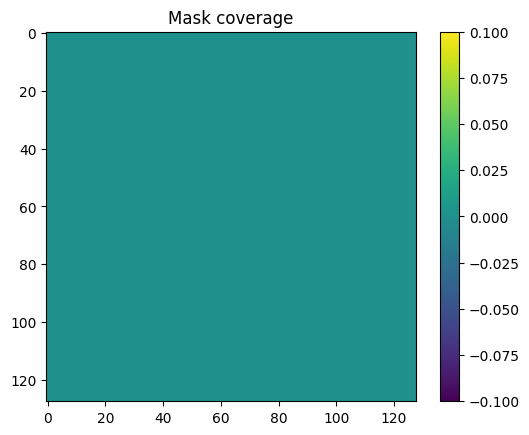

In [29]:
import matplotlib.pyplot as plt
m = mask[0].sum(dim=0)
plt.imshow(m)
plt.title("Mask coverage")
plt.colorbar()
plt.show()


Image batch shape: torch.Size([8, 3, 128, 128])
NIR batch shape: torch.Size([8, 1, 128, 128])


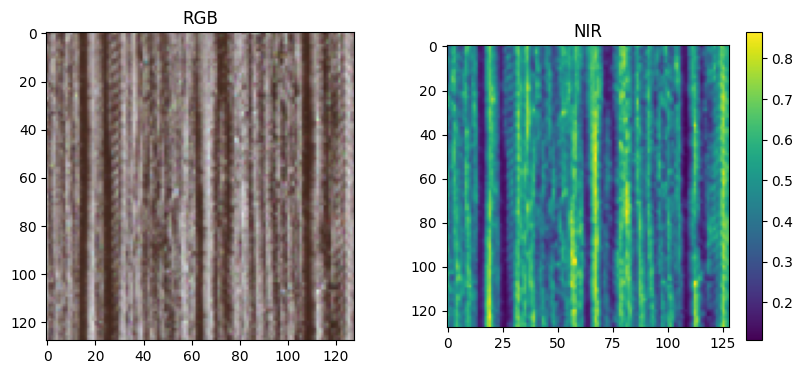

In [7]:
import matplotlib.pyplot as plt

# Fetch a batch
batch = next(iter(loader['train']))
imgs = batch["image"]    # shape [B, C, H, W]
nir = batch["target"]  # shape [B, 1, H, W]
print(f"Image batch shape: {imgs.shape}")
print(f"NIR batch shape: {nir.shape}")

# plot first sample
i = 0
img = imgs[i].numpy()
nd = nir[i].numpy()[0]

# normalize each RGB channel for visualization only
rgb_show = np.stack([
    img[0],
    img[1],
    img[2]
], axis=-1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(rgb_show)
plt.title("RGB")

plt.subplot(1,2,2)
plt.imshow(nd)
plt.title("NIR")
plt.colorbar()
plt.show()


Images: torch.Size([8, 3, 128, 128])
dtype: torch.float32
min/max: 0.0 1.0


IndexError: index 8 is out of bounds for axis 0 with size 8

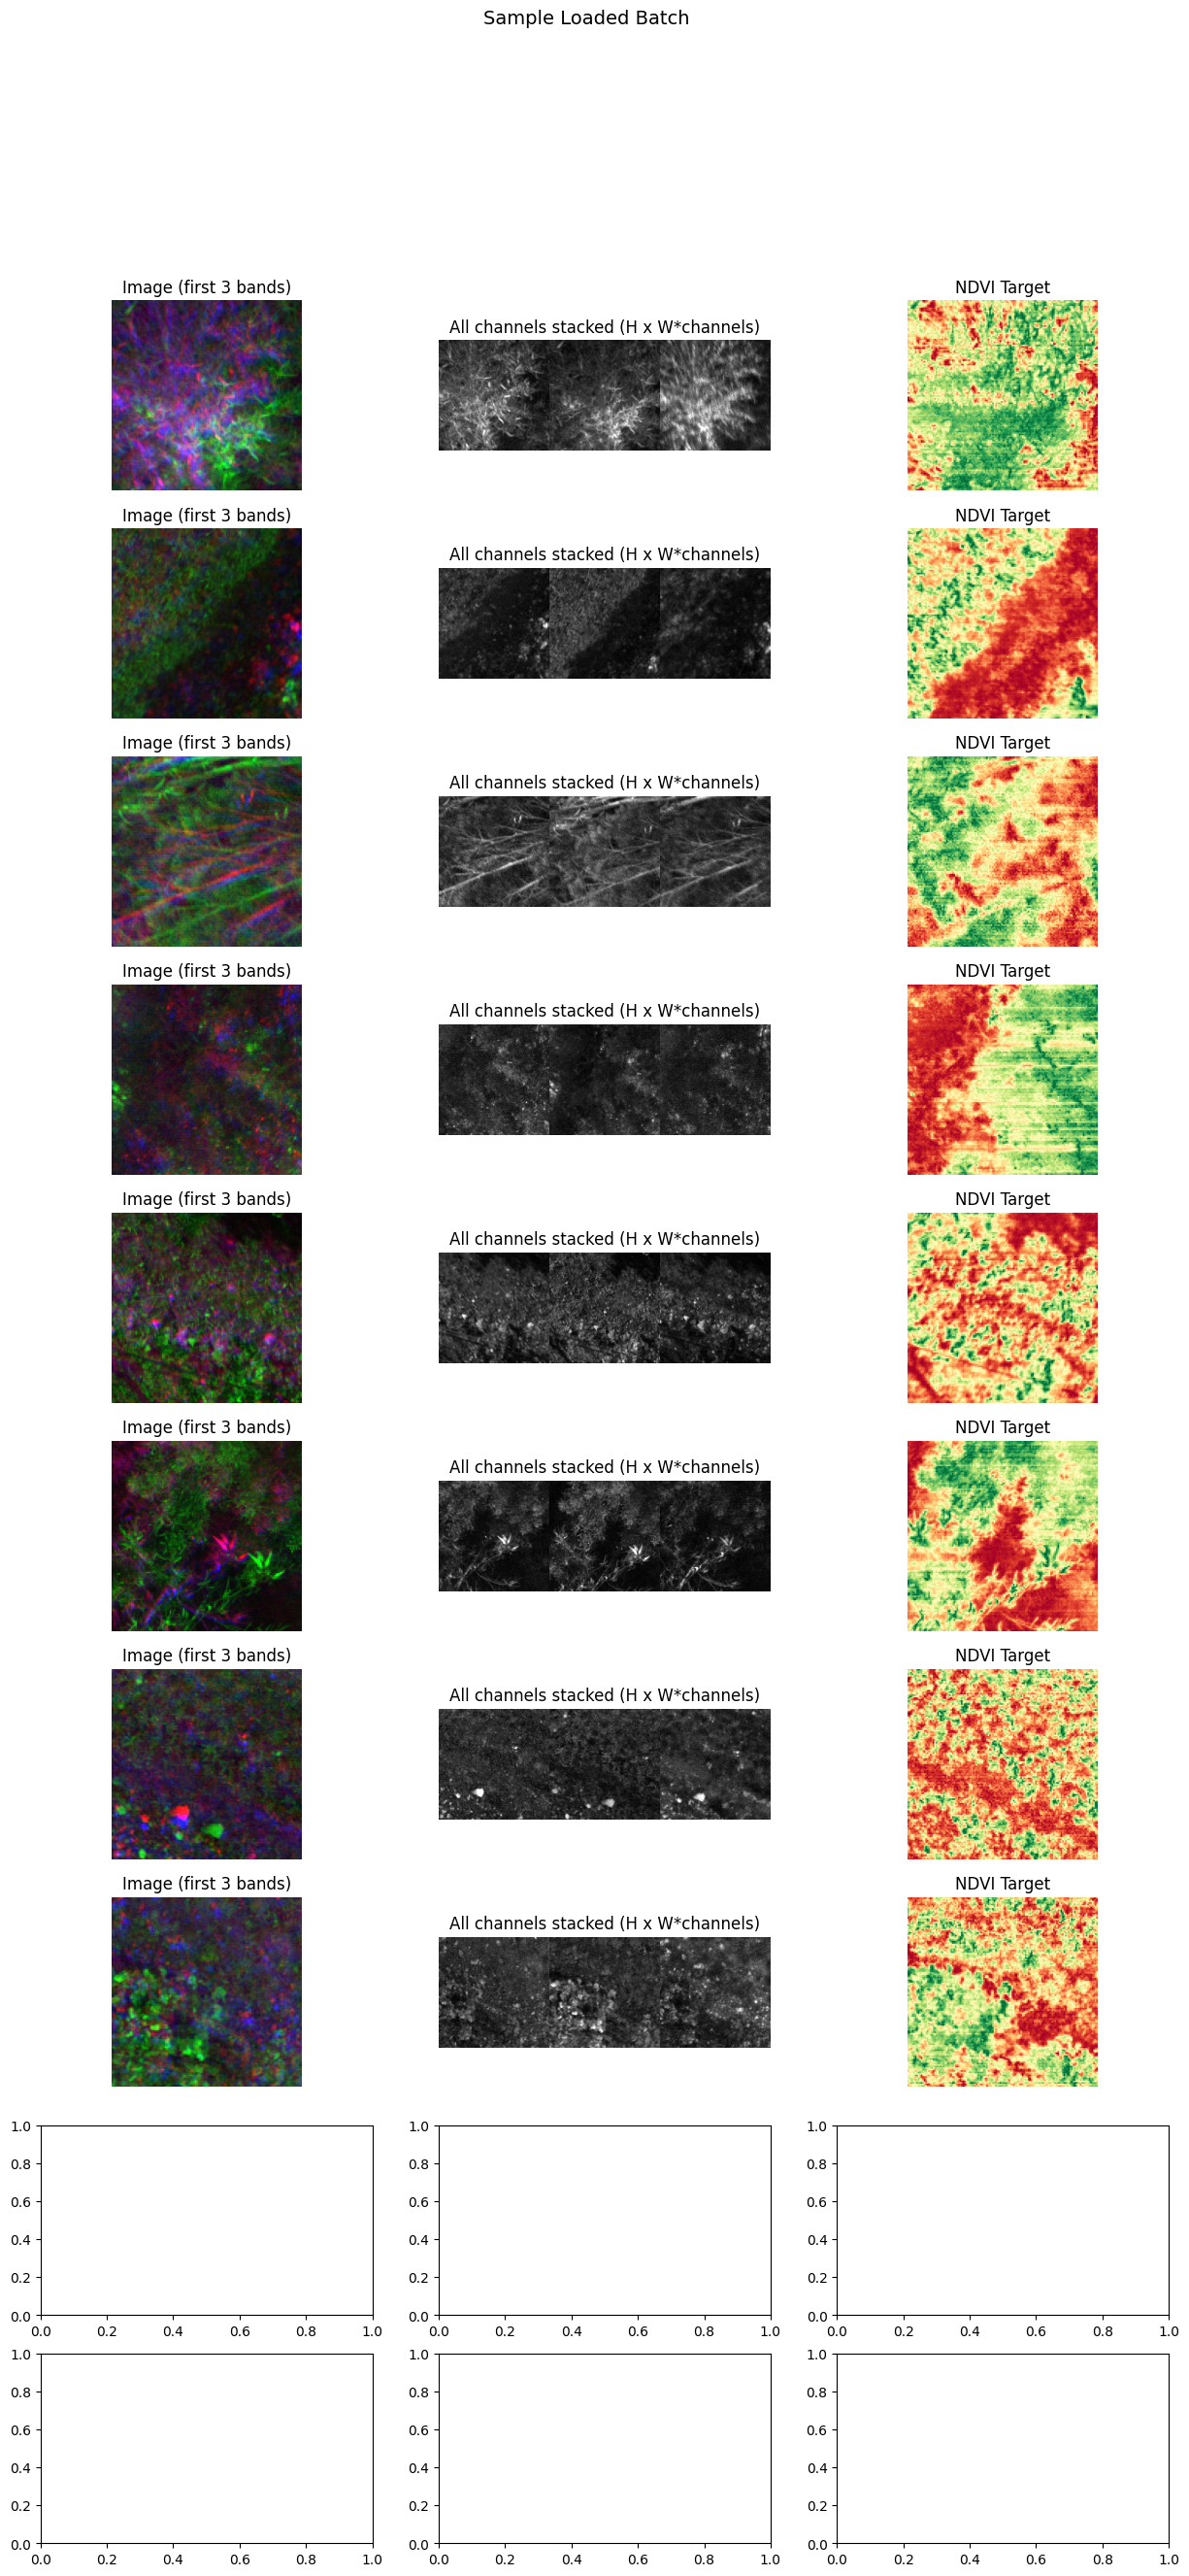

In [12]:
# import torch
# from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
from torch.utils.tensorboard import SummaryWriter


TEST_BATCH = 10

use_tensorboard = True
if use_tensorboard:
    writer = SummaryWriter(log_dir="./tb_debug_dataset")

batch = next(iter(loader['test']))
images,filename = batch["image"], None
target = batch["target"]

print("Images:", images.shape)
print("dtype:", images.dtype)
print("min/max:", images.min().item(), images.max().item())


# ------------------------------
# Display helper (fixes 6-channel issue)
# ------------------------------
def show_batch(imgs, target, filename, title="Batch"):
    imgs_np = imgs[:TEST_BATCH].detach().cpu().numpy()
    target_np = target[:TEST_BATCH].detach().cpu().numpy()

    fig, axes = plt.subplots(TEST_BATCH, 3, figsize=(15, TEST_BATCH * 3))
    fig.suptitle(title, fontsize=14)

    for i in range(TEST_BATCH):
        img = imgs_np[i]
        target_show = target_np[i]

        # ----------------------------------------
        # Option A — visualize only RGB channels
        # ----------------------------------------
        if img.shape[0] >= 3:
            axes[i, 0].imshow(np.transpose(img[:3], (1, 2, 0)))
            if filename is not None:
                axes[i, 0].set_title(f"Image {i} ({filename[i]}) (first 3 bands)")
            else:
                axes[i, 0].set_title(f"Image (first 3 bands)")
        # else:
        #     axes[i, 0].imshow(img[0], cmap="gray")
        #     axes[i, 0].set_title(f"Image {i} ({filename[i]}) (grayscale)")

        axes[i, 0].axis("off")

        # ----------------------------------------
        # Option B — show each channel in grayscale
        # ----------------------------------------
        axes[i, 1].imshow(
            np.hstack([img[c] for c in range(img.shape[0])]),
            cmap="gray"
        )
        axes[i, 1].set_title(f"All channels stacked (H x W*channels)")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(target_show[0], cmap="RdYlGn")
        axes[i, 2].set_title(f"NDVI Target")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


show_batch(images, target, filename, title="Sample Loaded Batch")


# ------------------------------
# TensorBoard visualization
# ------------------------------
if use_tensorboard:
    # Only log first 3 channels
    grid = make_grid(images[:, :3], nrow=2, normalize=False)
    writer.add_image("debug/sample_images_RGB", grid, global_step=0)

    print("TensorBoard logs saved → run:")
    print("    %tensorboard --logdir ./tb_debug_dataset")


In [ ]:
!tensorboard --logdir ./tb_debug_dataset
!pwd


/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
TensorFlow installation not found - running with reduced feature set.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.20.0 at http://localhost:6006/ (Press CTRL+C to quit)
^C
/home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/notebooks


# Training

Your current perception stage is:

- Identity kernel
- Sobel X
- Sobel Y
- Laplacian

These force the NCA to rely on pre-defined edges, gradients, and residual patterns.
But NDVI prediction from RGB is a nonlinear, spectral inference task, so fixed spatial filters are too restrictive.

Why learnable kernels are better

Learnable local filters allow the NCA to discover:

spectral transforms hidden in RGB

canopy textures related to chlorophyll & water stress

vineyard row structure

disease spread patterns

anisotropic textures (shadows, orientation of rows)

scale-dependent patterns

This transforms the NCA from a “hand-crafted CNN+NCA hybrid” into a fully emergent spatial processor.

In [9]:
import numpy as np # Ensure numpy is imported for get_perception_kernels
import torch
from torch.nn import Module, Conv2d, SiLU, Parameter
# import torch.nn.functional as F
from torch.nn.init import kaiming_normal_

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = True if DEVICE == "cuda" else False # automatic mixed precision

# Helper to create default perception kernels
def get_perception_kernels(device=None, dtype=torch.float32):
    # 3x3 kernels: identity, sobel x, sobel y, laplacian
    id_k = np.array([[0, 0, 0],
                     [0, 1, 0],
                     [0, 0, 0]], dtype=np.float32)
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=np.float32) / 8.0
    sobel_y = np.array([[-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]], dtype=np.float32) / 8.0
    lap = np.array([[0, 1, 0],
                    [1, -4, 1],
                    [0, 1, 0]], dtype=np.float32) / 4.0

    kernels = np.stack([id_k, sobel_x, sobel_y, lap], axis=0)  # (K, 3, 3)
    kernels = torch.from_numpy(kernels).to(device=device, dtype=dtype)  # (K, 3, 3)
    return kernels  # (K, 3, 3)


class PerceptionModule(Module):
    """
    Produces multi-scale perception map (B, C*K, H, W) from state (B,C,H,W).
      - depthwise 3x3 (groups=C) + pointwise 1x1 + SiLU + RMSNorm.
      - output channels = C * K.
    """
    def __init__(self,
                 state_channels: int,
                 kernel_count: int = 4):
        super().__init__()
        self.C = int(state_channels)
        self.K = int(kernel_count)
        cK = self.C * self.K

        self.depthwise = Conv2d(
            in_channels=self.C,
            out_channels=self.C,
            kernel_size=3,
            padding=1,
            groups=self.C,
            bias=False
        )

        self.pointwise = Conv2d(
            in_channels=self.C,
            out_channels=cK,
            kernel_size=1,
            padding=0,
            bias=False
        )

        self.act = SiLU()
        # GroupNorm(1, Ck) ~ InstanceNorm-style, stable & fast
        self.norm = RMSNorm(cK)
        # self.norm = GroupNorm(num_groups=1, num_channels=cK)

        # Kaiming init on conv kernels
        kaiming_normal_(self.depthwise.weight, nonlinearity="relu")
        kaiming_normal_(self.pointwise.weight, nonlinearity="relu")

    @property
    def out_channels(self) -> int:
        return self.C * self.K


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.act(x)
        x = self.norm(x)

        return x



# class PerceptionModule(Module):
#     """
#     Produces perception map (B, C*K, H, W) from state (B, C, H, W).
#     - If learnable=True: depthwise Conv2d (groups=C) with out_channels=C*K.
#     - If learnable=False: fixed kernels + grouped conv via F.conv2d.
#     - Includes robust per-channel normalization (no in-place).
#     """
#     def __init__(self,
#                  state_channels:int,
#                  kernel_count:int = 4,
#                  learnable:bool = True,
#                  eps:float = 1e-5,
#                  device=None,
#                  dtype=torch.float32):
#         super().__init__()
#         self.C = int(state_channels)
#         self.K = int(kernel_count)
#         self.learnable = bool(learnable)
#         self.eps = float(eps)
#         self.device = torch.device(device) if device is not None else None
#         self.dtype = dtype

#         if self.learnable:
#             self.perc_conv = Conv2d(
#                 in_channels=self.C,
#                 out_channels=self.C * self.K,
#                 kernel_size=3,
#                 padding=1,
#                 groups=self.C,
#                 bias=False,
#             )
#             kaiming_normal_(self.perc_conv.weight, nonlinearity='relu')
#         else:
#             base_kernels = get_perception_kernels(device=self.device, dtype=self.dtype)  # (K,3,3)
#             self.register_buffer("_fixed_kernels", base_kernels.unsqueeze(1).detach())   # (K,1,3,3)

#     def _expand_fixed_weight(self, dtype, device):
#         kernels = self._fixed_kernels    # (K,1,3,3)
#         K = kernels.shape[0]
#         C = self.C
#         w = kernels.unsqueeze(1).repeat(1, C, 1, 1, 1).view(K * C, 1, 3, 3)  # (C*K,1,3,3)
#         return w.to(dtype=dtype, device=device)

#     def forward(self, state: torch.Tensor):
#         _, C_in, _, _ = state.shape
#         assert C_in == self.C, f"PerceptionModule expected {self.C} channels, got {C_in}"

#         device = state.device
#         dtype = state.dtype

#         if self.learnable:
#             percep = self.perc_conv(state)  # (B, C*K, H, W)
#         else:
#             weight = self._expand_fixed_weight(dtype=dtype, device=device)
#             percep = F.conv2d(state, weight, bias=None, stride=1, padding=1, groups=C_in)

#         # Robust per-channel normalization (no in-place)
#         # percep: (B, Ck, H, W)
#         mean = percep.mean(dim=[2, 3], keepdim=True)  # (B,Ck,1,1)
#         var = percep.var(dim=[2, 3], unbiased=False, keepdim=True)  # (B,Ck,1,1)

#         # sanitize var
#         var = torch.nan_to_num(var, nan=0.0, posinf=1e3, neginf=0.0)
#         var_clamped = torch.clamp(var, min=0.0)
#         std = torch.sqrt(var_clamped + self.eps)  # SqrtBackward-safe

#         percep_norm = (percep - mean) / std
#         percep_norm = torch.clamp(percep_norm, -20.0, 20.0)  # avoid extremes

#         return percep_norm


class RMSNorm(Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.weight = Parameter(torch.ones(dim))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        norm = x.pow(2).mean(dim=1, keepdim=True).add(self.eps).sqrt()
        return self.weight[None, :, None, None] * x / norm


In [10]:
from torch.nn import Module, Conv2d, Sequential,SiLU
import torch.nn.functional as F

class WindowAttention(Module):
    def __init__(self, dim, num_heads=4, window_size=8):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.window = window_size

        self.scale = (dim // num_heads) ** -0.5

        self.qkv = Conv2d(dim, dim * 3, 1)
        self.proj = Conv2d(dim, dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)
        B, C, H, W = x.shape
        ws = self.window

        # pad to multiple of window
        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        x = F.pad(x, (0, pad_w, 0, pad_h))

        B, C, Hp, Wp = x.shape
        x = x.view(B, C, Hp // ws, ws, Wp // ws, ws)
        x = x.permute(0, 2, 4, 3, 5, 1).reshape(-1, ws * ws, C)

        qkv = self.qkv(x.transpose(1, 2).reshape(-1, C, 1, ws * ws))
        qkv = qkv.reshape(-1, 3, self.num_heads, C // self.num_heads, ws * ws)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]

        att = (q @ k.transpose(-2, -1)) * self.scale
        att = att.softmax(dim=-1)

        out = att @ v
        out = out.reshape(-1, C, ws, ws)

        # reverse window partition
        out = out.reshape(B, Hp // ws, Wp // ws, C, ws, ws)
        out = out.permute(0, 3, 1, 4, 2, 5).reshape(B, C, Hp, Wp)

        out = self.proj(out)
        return out[:, :, :H, :W]  # crop padding
    

class TransformerBlock(Module):
    def __init__(self, dim, num_heads=4, window=8):
        super().__init__()
        self.attn = WindowAttention(dim, num_heads, window)
        self.norm1 = RMSNorm(dim)

        self.mlp = Sequential(
            Conv2d(dim, dim * 2, 1),
            SiLU(),
            Conv2d(dim * 2, dim, 1),
        )
        self.norm2 = RMSNorm(dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


## Class Model (ARC-NCA) (+ hidden channels initialization)

In [11]:
# - Maintains a per-cell state: [Input Data (fixed) | hidden channels | NDVI out | alive mask].
#- Uses local perception via a small bank of 3×3 kernels (identity, Sobel X, Sobel Y, Laplacian) applied per channel.
#- Aggregates perception features with a 1×1 conv and passes them through a small MLP (implemented as 1×1 convs) to compute dx (the per-cell update).
# - Applies a stochastic update mask (fire_rate) per step so only a fraction of cells update each iteration (stabilizes training).
# - Clips alive and NDVI channels to keep values stable.
# - Supports iterative rollout (multiple NCA steps).

from torch.nn import Module, Conv2d, Parameter, Sequential, SiLU
from torch.nn.init import zeros_
import torch.nn.functional as F
from typing import Dict, Optional, Tuple
from torch.utils.checkpoint import checkpoint
import torch
from torchmetrics import Metric

# -------------------------
# Small SSIM implementation (single-scale) in pure PyTorch
# -------------------------
# def _gaussian_kernel(channels: int = 1,
#                      kernel_size: int = 11,
#                      sigma: float = 1.5,
#                      device=None,
#                      dtype=torch.float32,
#                      eps: float = 1e-8
#                      ) -> torch.Tensor:
#     """
#     Build a (C,1,k,k) gaussian kernel for grouped conv.
#     """
#     ax = torch.arange(kernel_size, dtype=dtype, device=device) - (kernel_size - 1) / 2.0
#     xx, yy = torch.meshgrid(ax, ax, indexing='xy')
#     kernel = torch.exp(-(xx ** 2 + yy ** 2) / (2.0 * sigma ** 2))
#     kernel = kernel / (kernel.sum() + eps)
#     kernel = kernel.view(1, 1, kernel_size, kernel_size) # (1,1,k,k)
#     kernel = kernel.repeat(channels, 1, 1, 1)  # (C,1,k,k) for groups=C
#     return kernel

class SSIMMap(Module):
    """
    TorchMetrics-style SSIM (stateless, differentiable).

    Input:
        x, y: (B, C, H, W) in [0, L]
    Returns:
        mean_ssim: scalar tensor
        ssim_map: (B, C, H, W)
    """

    def __init__(
        self,
        kernel_size: int = 11,
        sigma: float = 1.5,
        K1: float = 0.01,
        K2: float = 0.03,
        L: float = 1.0,
        eps: float = 1e-6,
    ):
        super().__init__()
        self.kernel_size = kernel_size
        self.sigma = sigma
        self.K1 = K1
        self.K2 = K2
        self.L = L
        self.eps = eps

        self.register_buffer("window", torch.empty(0))  # lazily built

    def _build_window(self, C: int, device, dtype):
        coords = torch.arange(self.kernel_size, device=device, dtype=dtype)
        coords -= self.kernel_size // 2

        g = torch.exp(-(coords**2) / (2 * self.sigma**2))
        g = g / g.sum()

        kernel_2d = torch.outer(g, g)
        kernel_2d = kernel_2d.expand(C, 1, -1, -1)

        self.window = kernel_2d.contiguous()

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        assert x.shape == y.shape, "SSIM inputs must have same shape"
        B, C, H, W = x.shape

        if self.window.numel() == 0 or self.window.shape[0] != C:
            self._build_window(C, x.device, x.dtype)

        # sanitize
        x = torch.nan_to_num(x, nan=0.0, posinf=1.0, neginf=0.0)
        y = torch.nan_to_num(y, nan=0.0, posinf=1.0, neginf=0.0)

        pad = self.kernel_size // 2

        mu_x = F.conv2d(x, self.window, padding=pad, groups=C)
        mu_y = F.conv2d(y, self.window, padding=pad, groups=C)

        mu_x2 = mu_x.pow(2)
        mu_y2 = mu_y.pow(2)
        mu_xy = mu_x * mu_y

        sigma_x2 = F.conv2d(x * x, self.window, padding=pad, groups=C) - mu_x2
        sigma_y2 = F.conv2d(y * y, self.window, padding=pad, groups=C) - mu_y2
        sigma_xy = F.conv2d(x * y, self.window, padding=pad, groups=C) - mu_xy

        sigma_x2 = sigma_x2.clamp_min(self.eps)
        sigma_y2 = sigma_y2.clamp_min(self.eps)

        C1 = (self.K1 * self.L) ** 2
        C2 = (self.K2 * self.L) ** 2

        num = (2 * mu_xy + C1) * (2 * sigma_xy + C2)
        den = (mu_x2 + mu_y2 + C1) * (sigma_x2 + sigma_y2 + C2)

        ssim_map = num / (den + self.eps)
        ssim_map = ssim_map.clamp(0.0, 1.0)

        mean_ssim = ssim_map.mean()

        return mean_ssim, ssim_map


class SSIMMetric(Metric):
    """
    Accumulating SSIM metric.
    """

    def __init__(self, **ssim_kwargs):
        super().__init__()
        self.ssim = SSIMMap(**ssim_kwargs)

        self.add_state("sum_ssim", default=torch.tensor(0.0), dist_reduce_fx="sum")
        self.add_state("count", default=torch.tensor(0), dist_reduce_fx="sum")

    def update(self, pred: torch.Tensor, target: torch.Tensor):
        ssim_mean, _ = self.ssim(pred, target)
        self.sum_ssim += ssim_mean
        self.count += 1

    def compute(self):
        return self.sum_ssim / self.count.clamp_min(1)


# class CombinedLoss(Module):
#     """
#     L1 + λ * (1 - SSIM),
#     SSIM is fully differentiable but numerically guarded.
#     """
#     def __init__(self, 
#             lambda_ssim: float = 0.1,
#             ssim_kwargs: Optional[Dict[str, Any]] = None
#         ):
#         super().__init__()
#         self.l1_loss = L1Loss()
#         self.lambda_ssim = float(lambda_ssim)
#         self.ssim_kwargs = ssim_kwargs or {"kernel_size": 11, "sigma": 1.5}

#     def forward(self, pred: torch.Tensor, target: torch.Tensor):
#         """
#         pred, target: (B,1,H,W) in [-1,1]f or [0,1]
#         SSIM is computed in float32 under no_grad and detached.
#         """
#         l1 = self.l1_loss(pred, target)

#         # scale to [0,1] if needed
#         if pred.min() < -0.5 and target.min() < -0.5:
#             p = (pred + 1.0) / 2.0
#             t = (target + 1.0) / 2.0
#         else:
#             p = pred
#             t = target

#         # Compute SSIM with gradients
#         ssim_mean, _ = ssim_map(p, t, **self.ssim_kwargs)
#         # Safe clamp for numerics but keeps grad
#         ssim_mean = ssim_mean.clamp(0.0, 1.0)

#         ssim_mean = torch.nan_to_num(ssim_mean, nan=0.0).clamp(0, 1)

#         loss = l1 + self.lambda_ssim * (1.0 - ssim_mean)
#         return loss

# class NIRNDVILoss(Module):
#     """
#     Hybrid loss:
#       L = L1(NIR) + λ_ndvi * L1(NDVI) + λ_ssim * (1 - SSIM(NDVI))
#     """
#     def __init__(self,
#                  lambda_ndvi: float = 0.3,
#                  lambda_ssim: float = 0.1,
#                  ssim_kwargs: Optional[Dict[str, Any]] = None):
#         super().__init__()
#         self.l1 = L1Loss()
#         self.lambda_ndvi = float(lambda_ndvi)
#         self.lambda_ssim = float(lambda_ssim)
#         self.ssim_kwargs = ssim_kwargs or {"kernel_size": 11, "sigma": 1.5}

#     def forward(self,
#                 rgb: torch.Tensor,      # (B,3,H,W) – same scaling as nir
#                 nir_pred: torch.Tensor, # (B,1,H,W)
#                 nir_true: torch.Tensor  # (B,1,H,W)
#                 ) -> torch.Tensor:
#         # --- 1. NIR reconstruction ---
#         nir_pred = torch.nan_to_num(nir_pred, nan=0.0, posinf=3.0, neginf=-3.0)
#         nir_true = torch.nan_to_num(nir_true, nan=0.0, posinf=3.0, neginf=-3.0)
#         l1_nir = self.l1(nir_pred, nir_true)

#         # --- 2. NDVI consistency ---
#         ndvi_pred = compute_ndvi_from_rgb_nir(rgb, nir_pred)
#         ndvi_true = compute_ndvi_from_rgb_nir(rgb, nir_true)
#         l1_ndvi = self.l1(ndvi_pred, ndvi_true)

#         # --- 3. Structural consistency via SSIM on NDVI ---
#         ssim_mean, _ = ssim_map(ndvi_pred, ndvi_true, **self.ssim_kwargs)
#         ssim_mean = torch.nan_to_num(ssim_mean, nan=0.0).clamp(0.0, 1.0)

#         loss = l1_nir \
#              + self.lambda_ndvi * l1_ndvi \
#              + self.lambda_ssim * (1.0 - ssim_mean)

#         return loss


# Bundle perception mixer + update net into a single module
class PerceptionUpdate(Module):
    """
    Takes perception features and outputs dx_raw (B, 2*U, H, W) 
    where U = state_channels - input_channels.
    """
    def __init__(self, pe_feat: int, hidden_dim: int, U: int):
        super().__init__()
        self.proj_in = Conv2d(pe_feat, hidden_dim, kernel_size=1)
        self.net = Sequential(
            Conv2d(hidden_dim, hidden_dim, kernel_size=1),
            SiLU(),
            Conv2d(hidden_dim, hidden_dim, kernel_size=1),
            SiLU(),
        )
        self.proj_out = Conv2d(hidden_dim, 2 * U, kernel_size=1)

        # initialize last layer to near-zero for stable start
        zeros_(self.proj_out.weight)
        if self.proj_out.bias is not None:
            zeros_(self.proj_out.bias)

    def forward(self, percep: torch.Tensor) -> torch.Tensor:
        x = self.proj_in(percep)
        res = x
        x = self.net(x)
        x = x + res
        dx_raw = self.proj_out(x)
        return dx_raw

class ARC_NCA(Module):
    """
    ARC-style Neural Cellular Automaton implementation.
    State layout (channels):
      [ 0 : input_data_channels )
      [ input_data_channels : input_data_channels + hidden_channels ) -> hidden
      [ input_data_channels + hidden_channels : + out_channels )     -> NDVI out
      [ last channel ] -> alive mask
    The model will keep input_data_channels constant (as a conditioning input) and only update hidden, output, and alive channels.
      - Learnable perception (or fixed kernels)
      - Mixed Precision support (AMP)
      - Randomized rollout
      - Safe NDVI prediction
      - channel dropout (training)
      - Explicit initial state builder
      - Fire-rate stochastic updates
    """
    def __init__(self,
                input_data_channels: int =3, # Renamed from in_rgb_channels
                hidden_channels: int =16,
                out_channels: int =1,  # NDVI
                fire_rate: float = 0.5,
                kernel_count: int = 2,  # Number of perception kernels
                hidden_dim: int = 128,
                channel_dropout_prob: float = 0.0, # By default, no channel dropout
                delta_clip: float = 1.0,
                noise_std: float = 0.0,
                use_spatial_gate: bool = False,
                use_checkpoint: bool = True,
                device: torch.device = DEVICE # Use the global DEVICE constant
                ): 
        super().__init__()

        # Ensure device is a torch.device object
        self.device = torch.device(device) if isinstance(device, str) else device

        self.input_data_channels = int(input_data_channels)
        self.hidden = int(hidden_channels)
        self.out = int(out_channels)
        self.alive = 1
        self.state_channels = self.input_data_channels + self.hidden + self.out + self.alive
        # self.learnable_perception = bool(learnable_perception)
        # perception configuration
        # self.fixed_perceive_kernels = get_perception_kernels(device=self.device) if perceive_kernels is None else perceive_kernels.to(self.device)
        # self.perception_kernel_count = 4 if perceive_kernels is None else perceive_kernels.shape[0]
        self.fire_rate = float(fire_rate)
        self.use_spatial_gate = bool(use_spatial_gate)
        self.use_checkpoint = bool(use_checkpoint)
        self.channel_dropout_prob = float(channel_dropout_prob)
        self.delta_clip = float(delta_clip)
        self.noise_std = float(noise_std)


        # Perception module
        # self.perception = PerceptionModule(state_channels=self.state_channels,
        #                                 kernel_count=self.perception_kernel_count,
        #                                 learnable=self.learnable_perception,
        #                                 eps=1e-5,
        #                                 device=self.device,
        #                                 dtype=torch.float32)
        self.perception = PerceptionModule(
            state_channels=self.state_channels,
            kernel_count=kernel_count, # 4 kernels (id-like, edge-like capacity per channel)
        )

        # perception: either fixed kernels (buffer) or learnable depthwise conv
        # Option A: learned depthwise conv (groups = C, out = C * K)
        # The output of this conv will be shape (B, C*K, H, W)
        # if self.learnable_perception:
        #     # depthwise conv: groups = channels -> we will create Conv2d with in_channels=C, out=C*K via grouped operations
        #     # to keep it simple, implement as a grouped conv: use depthwise conv per kernel then concatenate
        #     self.perc_conv = Conv2d(self.state_channels, self.state_channels * self.perception_kernel_count,
        #                                kernel_size=3, padding=1, groups=self.state_channels, bias=False)
        #     # small weight init
        #     kaiming_normal_(self.perc_conv.weight, nonlinearity='relu')
        #     # no fixed kernel buffer needed at runtime
        #     self.register_buffer("perceive_kernels_buffer", torch.zeros(1))
        # else:
        #     # Option B: fixed kernels path (existing behavior)
        #     # Keep the get_perception_kernels buffers + expanded weight approach
        #     self.register_buffer("perceive_kernels_buffer", self.fixed_perceive_kernels.clone().detach())


        # instance normalization to stabilize perception outputs
        # Perception update head (1x1 MLP)
        self.U = self.state_channels - self.input_data_channels # non-input channels
        pe_feat = self.perception.out_channels + self.hidden
        
        # Update net
        self.update_net  = PerceptionUpdate(pe_feat=pe_feat, hidden_dim=hidden_dim, U=self.U)

        # Learned delta scaling (small initial)
        self.delta_scale = Parameter(torch.tensor(0.1, dtype=torch.float32))

        # Learnable blend for NDVI update (0..1 after sigmoid)
        self.out_blend_logit = Parameter(torch.tensor(0.0, dtype=torch.float32))

        # Fire rate (buffer)
        # self.register_buffer(
        #     "fire_rate",
        #     torch.tensor(float(fire_rate), dtype=torch.float32, device=self.device)
        # )

        # --- CNN Stem + Transformer Encoder ---
        self.stem = Sequential(
            Conv2d(input_data_channels, 32, 3, padding=1),
            SiLU(),
            Conv2d(32, 32, 3, padding=1),
            SiLU(),
        )

        self.transformer = TransformerBlock(dim=32, num_heads=4, window=8)

        # Bottleneck → compress transformer features into hidden channels
        self.feat_to_hidden = Conv2d(32, self.hidden, 1)
        self.hidden_proj = Conv2d(self.hidden, self.perception.out_channels, 1)


        if self.use_spatial_gate:
            self.spatial_gate = Conv2d(
                self.state_channels, 1, kernel_size=3, padding=1, bias=False
            )
            kaiming_normal_(self.spatial_gate.weight, nonlinearity="sigmoid")

        # Move modules to device
        self.to(self.device, memory_format=torch.channels_last)


    # def expand_perception_weight(self, device, dtype):
    #     """
    #     Build grouped conv weight of shape (C*K, 1, 3, 3)
    #     To be used with F.conv2d(input, weight, groups=C)
    #     where input has shape (B, C, H, W) and groups=C.
    #     """
    #     kernels = self.perceive_kernels  # (K,3,3)
    #     K = kernels.shape[0]
    #     C = self.state_channels
    #     # kernels.unsqueeze(1) -> (K,1,3,3), repeat for channels -> (K,C,3,3), view (C*K,1,3,3)
    #     weight = kernels.unsqueeze(1).repeat(1, C, 1, 1).view(K * C, 1, 3, 3)
    #     return weight.to(device=device, dtype=dtype)


    # Manual per-channel normalization: stable, small eps
    def _manual_percep_norm(self, percep: torch.Tensor) -> torch.Tensor:
        # percep: (B, Ck, H, W)
        B, Ck, H, W = percep.shape

        # Mean and variance
        percep = torch.nan_to_num(percep, nan=0.0, posinf=1e5, neginf=-1e5)
        mean = percep.mean(dim=[2,3], keepdim=True)
        var = (percep - mean).pow(2).mean(dim=[2,3], keepdim=True)
        std = torch.sqrt(var + self.eps)

        percep = (percep - mean) / std

        # Replace NaN/Inf defensively
        percep = torch.nan_to_num(percep, nan=0.0, posinf=1e2, neginf=-1e2)

        return percep

    def perceive(self, state) -> torch.Tensor:
        """
        x: (B, C, H, W) where C == self.state_channels
        returns: perception map with shape (B, C*K, H, W)
        """
        # returns (B, C*K, H, W) already normalized
        return self.perception(state)

    def perceive_and_update(self, state:torch.Tensor) -> torch.Tensor:
        percep = self.perception(state)

        # Instead of large concatenations, fuse hidden via 1×1 conv
        hidden = state[:, self.input_data_channels:self.input_data_channels+self.hidden]
        hidden_proj = self.hidden_proj(hidden)  # small conv

        fused = percep + hidden_proj  # elementwise → cheaper & faster
        return self.update_net(fused)


    def stochastic_update_mask(self, shape, dtype, device) -> torch.Tensor:
        """
        Returns a Bernoulli mask with probability = fire_rate that determines which cells update.
        mask = 1.0 if rand < fire_rate, else 0.0
        shape: (B, 1, H, W)
        """
        prob = float(self.fire_rate)
        # Draw uniform random and compare
        # Ensure mask is on the correct device
        rnd = torch.rand(shape, device=device, dtype=dtype)
        return (rnd <= prob).to(dtype=torch.float32)

    # optional channel dropout for hidden channels during training
    def _channel_dropout(self, state: torch.Tensor)-> torch.Tensor:
        """
        Dropout on non-input channels (hidden+out+alive), no in-place.
        """
        if (not self.training) or self.channel_dropout_prob <= 0.0:
            return state

        B, C, H, W = state.shape
        p = self.channel_dropout_prob

        C_in = self.input_data_channels

        input_part = state[:, :C_in, :, :]
        tail_part = state[:, C_in:, :, :]  # (B,U,H,W)

        # Bernoulli keep mask: 1 with prob (1-p)
        keep_mask = (torch.rand((B, self.U, 1, 1), device=state.device) > p).to(state.dtype)
        tail_dropped = tail_part * keep_mask

        return torch.cat([input_part, tail_dropped], dim=1)

    # ----------------------
    # Single NCA step
    # ----------------------
    def _step_core(self, state: torch.Tensor) -> torch.Tensor:
        B, C, H, W = state.shape
        device = state.device
        dtype = state.dtype

        # Optional channel dropout
        state = self._channel_dropout(state)

        # Optional noise on hidden channels (training only)
        if self.training and self.noise_std > 0.0:
            noise = torch.zeros_like(state)
            h_start = self.input_data_channels
            h_end = h_start + self.hidden
            noise[:, h_start:h_end] = self.noise_std * torch.randn(
                (B, self.hidden, H, W), device=device, dtype=dtype
            )
            state = state + noise

        # Alive mask from last channel
        alive_idx = self.state_channels - 1
        alive_mask = state[:, alive_idx:alive_idx + 1, :, :]  # (B,1,H,W)

        # Split input + tail to get hidden for temporal skip
        C_in = self.input_data_channels
        input_part = state[:, :C_in, :, :]            # (B,C_in,H,W)
        tail_old = state[:, C_in:, :, :]              # (B,U,H,W)
        h = self.hidden
        o = self.out
        a = self.alive
        hidden_old, out_old, alive_old = torch.split(tail_old, [h, o, a], dim=1)

        percep = self.perception(state)
        percep = torch.cat([percep, hidden_old], dim=1)

        # Update net
        dx_raw = self.update_net(percep)  # (B,2*U,H,W)
        dx_raw = dx_raw.view(B, 2, self.U, H, W)
        delta_raw = dx_raw[:, 0]  # (B,U,H,W)
        gate_raw = dx_raw[:, 1]   # (B,U,H,W)

        # Gate logits -> sigmoid
        gate = torch.sigmoid(torch.clamp(gate_raw, -8.0, 8.0))

        # Scaled + clipped deltas
        delta_scaled = delta_raw * self.delta_scale.tanh()
        delta_clipped = torch.clamp(delta_scaled, -self.delta_clip, self.delta_clip)

        # Fire mask
        fire_mask = self.stochastic_update_mask(
            shape=(B, 1, H, W), dtype=dtype, device=device
        )  # (B,1,H,W)

        update_mask = fire_mask * alive_mask
        update_mask = update_mask.expand(-1, self.U, -1, -1)  # (B,U,H,W)

        delta_applied = delta_clipped * gate * update_mask  # (B,U,H,W)

        # Optional spatial gate
        if self.use_spatial_gate:
            spatial_mask = torch.sigmoid(self.spatial_gate(state))
            delta_applied = delta_applied * spatial_mask

        # Tail update
        tail_new_raw = tail_old + delta_applied
        hidden_raw, out_raw, alive_raw = torch.split(tail_new_raw, [h, o, a], dim=1)

        # Hidden update: soft residual + tanh, with clamp
        hidden_new = 0.9 * hidden_old + 0.1 * torch.tanh(hidden_raw)
        hidden_new = torch.clamp(hidden_new, -2.0, 2.0)

        # NDVI update: attention-like residual
        alpha = torch.sigmoid(self.out_blend_logit)  # scalar in (0,1)
        beta = torch.sigmoid(out_raw)                # (B,1,H,W)
        out_new = out_old + alpha * beta * (out_raw - out_old)
        out_new = torch.clamp(out_new, -1.0, 1.0)

        # Alive persistence: mix old and new
        alive_raw_sig = torch.sigmoid(alive_raw)
        alive_new = 0.5 * alive_old + 0.5 * alive_raw_sig
        alive_new = torch.clamp(alive_new, 0.1, 1.0)  # never fully dead

        tail_new = torch.cat([hidden_new, out_new, alive_new], dim=1)

        # Final state
        new_state = torch.cat([input_part, tail_new], dim=1)
        new_state = torch.nan_to_num(new_state, nan=0.0, posinf=3.0, neginf=-3.0)
        new_state = torch.clamp(new_state, -3.0, 3.0)
        return new_state

    def step(self, state: torch.Tensor) -> torch.Tensor:
        if self.use_checkpoint and state.requires_grad:
            return checkpoint(self._step_core, state, use_reentrant=False)
        else:
            return self._step_core(state)

    # State initialization
    def initialize_state(self, input_data: torch.Tensor, priors: dict | None = None) -> torch.Tensor:
        """
        Build initial state from input_data and optional priors.
        priors may contain:
          - "masks": (B, N_masks, H, W)
          - "positional_channels":   (B, 4, H, W)
        """
        B, C_in, H, W = input_data.shape
        device = input_data.device
        dtype = input_data.dtype

        if C_in != self.input_data_channels:
            raise ValueError(
                f"input_data has {C_in} channels but model expects {self.input_data_channels}"
            )

        feat = self.stem(input_data)
        feat = self.transformer(feat)
        hidden = self.feat_to_hidden(feat)  # shape: (B, hidden, H, W)
        out = torch.zeros((B, self.out, H, W), device=device, dtype=dtype)
        alive = (input_data.sum(dim=1, keepdim=True) > 0).float().to(device=device, dtype=dtype)

        if priors is not None:
            masks = priors.get("mask", None)
            pos   = priors.get("positional_channels", None)

            if masks is not None:
                if masks.shape[0] != B:
                    raise ValueError("masks batch size mismatch")
                n = masks.shape[1]
                use_n = min(n, self.hidden)
                hidden[:, :use_n, :, :] = masks[:, :use_n, :, :].to(device=device, dtype=dtype)

            if pos is not None:
                if pos.shape[0] != B:
                    raise ValueError("pos batch size mismatch")
                start = 0
                if masks is not None:
                    n = masks.shape[1]
                    start = min(n, self.hidden)
                remain = self.hidden - start
                use_p = min(4, remain)
                if use_p > 0:
                    hidden[:, start:start+use_p, :, :] = pos[:, :use_p, :, :].to(device=device, dtype=dtype)

        state = torch.cat([input_data, hidden, out, alive], dim=1)
        return state


    def forward(
        self,
        input_data: torch.Tensor,
        steps: int = 32,
        fire_rate: Optional[float] = None,
        priors: Optional[Dict] = None
    ) -> torch.Tensor:

        input_data = input_data.to(self.device)
        state = self.initialize_state(input_data, priors=priors)

        if fire_rate is not None:
            self.fire_rate = float(fire_rate)

        for _ in range(steps):
            state = self.step(state)

        return state

    def predict_ndvi(self, state: torch.Tensor)-> torch.Tensor:
        """
        xtract NDVI output channel from final state.
        state: (B, state_channels, H, W)
        returns (B,1,H,W)
        """
        ndvi_idx = self.input_data_channels + self.hidden
        # Ensure the slice is correct and covers only the output channels
        # Just use the first item of the Truple (final state)
        return state[:, ndvi_idx:ndvi_idx+self.out, :, :]

    def predict_nir(self, state: torch.Tensor) -> torch.Tensor:
        """
        Extract NIR output channel.
        state: (B, state_channels, H, W)
        """
        nir_idx = self.input_data_channels + self.hidden
        # nir_logits = state[:, nir_idx:nir_idx+1, :, :]
        # return torch.sigmoid(nir_logits)
        return state[:, nir_idx:nir_idx+1]


In [12]:
# model = ARC_NCA(
#         input_data_channels=3,
#         hidden_channels=32,
#         out_channels=1,
#         fire_rate=0.65,
#         hidden_dim=128,
#         channel_dropout_prob=0.00,
#         delta_clip=1.0,
#         noise_std=0.0,
#         use_checkpoint=False,
#         )

model = ARC_NCA(
        input_data_channels=3,
        hidden_channels=16,
        out_channels=1,
        fire_rate=0.65,
        hidden_dim=128,
        channel_dropout_prob=0.00,
        delta_clip=1.0,
        noise_std=0.0,
        use_checkpoint=False,
        )


# model = torch.compile(
#     model,
#     mode="reduce-overhead",
#     fullgraph=False,
#     dynamic=True,
# )


In [13]:
from typing import Optional
from torch.nn import Module
import torch

def save_checkpoint(model: Module, optimizer: torch.optim.Optimizer, epoch: int, loss: float, path: str):
    state = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "loss": loss
    }
    torch.save(state, path)

def load_checkpoint(path: str, model: Module, optimizer: Optional[torch.optim.Optimizer] = None, map_location=None):
    ck = torch.load(path, map_location=map_location,weights_only=False)
    model.load_state_dict(ck["model_state"])
    if optimizer is not None and "optimizer_state" in ck:
        optimizer.load_state_dict(ck["optimizer_state"])
    return ck.get("epoch", 0), ck.get("loss", None)


In [14]:
# ============================================================
# Nodata-aware CombinedLoss (NIR + optional NDVI + SSIM)
# - Works entirely on GPU
# - Ignores invalid pixels via valid masks
# - Avoids "loss=0 early" caused by invalid pixels set to 0
# ============================================================

import torch
from torch.nn import Module
import torch.nn.functional as F
from typing import Optional, Dict, Any


def compute_ndvi(red: torch.Tensor, nir: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """
    red: (B,1,H,W) scaled same way as nir (e.g. [0,1] or [-1,1])
    nir: (B,1,H,W)
    """
    ndvi = (nir - red) / (nir + red + eps)
    return torch.clamp(ndvi, -1.0, 1.0)


class CombinedLoss(Module):
    """
    Nodata-aware hybrid loss.

    Components:
      - NIR reconstruction: L1 or SmoothL1 on valid NIR pixels
      - Optional NDVI consistency: L1 on valid NDVI pixels (requires red + ndvi_valid_mask)
      - Optional SSIM term (on NDVI or NIR): computed after masking invalid pixels to zero

    You decide what you pass:
      forward(pred, target, valid_mask, red=None, ndvi_target=None, ndvi_valid_mask=None)

    Notes:
      - pred/target expected in [0,1] for NIR reflectance (recommended)
      - valid_mask is bool, shape (B,1,H,W)
    """

    def __init__(
        self,
        use_smooth_l1: bool = True,
        beta: float = 0.1,
        lambda_ssim: float = 0.0,
        lambda_ndvi: float = 0.0,
        ssim_on: str = "ndvi",  # "ndvi" or "nir"
        ssim_kwargs: Optional[Dict[str, Any]] = None,
    ):
        super().__init__()
        self.use_smooth_l1 = bool(use_smooth_l1)
        self.beta = float(beta)
        self.lambda_ssim = float(lambda_ssim)
        self.lambda_ndvi = float(lambda_ndvi)
        self.ssim_on = ssim_on
        self.ssim_kwargs = ssim_kwargs or {}

    def _masked_l1(self, pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # pred/target: (B,1,H,W), mask: bool (B,1,H,W)
        # avoids boolean indexing (can be memory heavy) using reduction
        mask_f = mask.to(dtype=pred.dtype)
        diff = (pred - target).abs()
        num = (diff * mask_f).sum()
        den = mask_f.sum().clamp_min(1.0)
        return num / den

    def _masked_smooth_l1(self, pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        mask_f = mask.to(dtype=pred.dtype)
        diff = F.smooth_l1_loss(pred, target, reduction="none", beta=self.beta)
        num = (diff * mask_f).sum()
        den = mask_f.sum().clamp_min(1.0)
        return num / den

    def _mask_to_zero(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # keep invalid pixels at 0 to avoid fabricating structure
        return torch.where(mask, x, torch.zeros_like(x))

    def forward(
        self,
        pred: torch.Tensor,                 # NIR pred (B,1,H,W)
        target: torch.Tensor,               # NIR true (B,1,H,W)
        valid_mask: Optional[torch.Tensor] = None,  # NIR valid mask (B,1,H,W) bool
        red: Optional[torch.Tensor] = None,         # RED reflectance (B,1,H,W) in [0,1]
        ndvi_target: Optional[torch.Tensor] = None, # optional precomputed NDVI (B,1,H,W)
        ndvi_valid_mask: Optional[torch.Tensor] = None,  # NDVI valid mask (B,1,H,W) bool
        ssim_map_fn: SSIMMap | None =None,                   # pass your ssim_map function here
    ) -> torch.Tensor:

        if valid_mask is None:
            valid_mask = torch.isfinite(target)
        valid_mask = valid_mask.bool()

        if valid_mask.sum() == 0:
            # Return a dummy zero that still participates in graph
            return pred.sum() * 0.0

        # sanitize
        pred_raw = pred
        target_raw = target

        pred = torch.nan_to_num(pred_raw, nan=0.0, posinf=1.0, neginf=0.0)
        target = torch.nan_to_num(target_raw, nan=0.0, posinf=1.0, neginf=0.0)

        # ---- NIR reconstruction loss ----
        if self.use_smooth_l1:
            nir_loss = self._masked_smooth_l1(pred, target, valid_mask)
        else:
            nir_loss = self._masked_l1(pred, target, valid_mask)

        loss = nir_loss

        # ---- NDVI consistency loss (optional) ----
        if self.lambda_ndvi > 0.0:
            if red is None:
                raise ValueError("lambda_ndvi > 0 but 'red' was not provided.")
            red = torch.nan_to_num(red, nan=0.0, posinf=1.0, neginf=0.0)

            if ndvi_valid_mask is None:
                # conservative: NDVI valid only where NIR valid AND red finite
                ndvi_valid_mask = valid_mask & torch.isfinite(red)
            ndvi_valid_mask = ndvi_valid_mask.bool()

            ndvi_pred = compute_ndvi(red, pred)
            if ndvi_target is None:
                ndvi_target = compute_ndvi(red, target)

            ndvi_target = torch.nan_to_num(ndvi_target, nan=0.0)

            ndvi_l = self._masked_smooth_l1(ndvi_pred, ndvi_target, ndvi_valid_mask)
            loss = loss + self.lambda_ndvi * ndvi_l

        # ---- SSIM term (optional) ----
        if self.lambda_ssim > 0.0:
            if ssim_map_fn is None:
                raise ValueError("lambda_ssim > 0 but ssim_map_fn was not provided.")

            if self.ssim_on.lower() == "nir":
                x = self._mask_to_zero(pred, valid_mask)
                y = self._mask_to_zero(target, valid_mask)
                # SSIM expects (B,C,H,W)
                # ssim_mean, _ = ssim_map_fn(x.float(), y.float(), **self.ssim_kwargs)
            else:
                # NDVI SSIM (preferred for structure)
                if red is None:
                    raise ValueError("SSIM on NDVI requires 'red' input.")
                if ndvi_valid_mask is None:
                    ndvi_valid_mask = valid_mask & torch.isfinite(red)
                ndvi_valid_mask = ndvi_valid_mask.bool()

                ndvi_pred = compute_ndvi(red, pred)
                ndvi_true = compute_ndvi(red, target)

                x = self._mask_to_zero(ndvi_pred, ndvi_valid_mask)
                y = self._mask_to_zero(ndvi_true, ndvi_valid_mask)
            ssim_mean, _ = ssim_map_fn(x, y)
                # ssim_mean, _ = ssim_map_fn(x.float(), y.float(), **self.ssim_kwargs)

            ssim_mean = torch.nan_to_num(ssim_mean, nan=0.0).clamp(0.0, 1.0)
            loss = loss + self.lambda_ssim * (1.0 - ssim_mean)

        return loss


Yes — for NDVI prediction using an ARC-NCA, replacing plain MSELoss with a perceptual / structure-aware loss is not only recommended, it usually improves:

- Sharpness of NDVI transitions

- Spatial consistency across vegetation patches

- Sensitivity to subtle canopy texture

- Generalization across lighting/geometric variations

MSE punishes large errors heavily, but:

- NDVI ranges only from −1 to 1 → MSE gradients become tiny

- UAV NDVI ground truth contains sensor noise → MSE overfits noise

- MSE does not care about spatial structure, only per-pixel match

ARC-NCA produces iterative fields, not direct CNN predictions
→ MSE does not enforce stable spatial dynamics

So NDVI trained with pure MSE tends to be:

too smooth

blurry around canopy boundaries

unstable in rollout

often underestimates high NDVI values

📌 Better losses for NDVI ARC-NCA

You listed the 3 best candidates. Here is how they fit in this context:

⭐ 1. L1 Loss (MAE)

Highly recommended as a base loss.

Benefits:

preserves edge boundaries

more aligned with NDVI absolute error metrics

robust to outliers

incentizes correct median, not mean

MAE usually improves NDVI prediction in vegetation or remote sensing tasks.

In most NDVI regressors (UNet, CNN, ViT), MAE > MSE.

⭐ 2. SSIM or MS-SSIM

This is huge for NCAs.
SSIM focuses on:

local contrast

luminance

structure (e.g., edges, textures)

Since vegetation canopy patterns are locally structured, SSIM acts like a “perceptual loss”.

For NDVI maps, SSIM helps the NCA learn:

canopy discontinuities

inter-row vegetation structure

shadows & occlusion consistency

patch smoothness without blurring

MS-SSIM gives even clearer structure stability, especially for 128–512 px tiles.

⭐ 3. Combined Loss: L1 + λ (1 − SSIM)

This is the best performing loss in practice for image-to-image regression tasks.

Typical formula:
Loss = MAE + λ * (1 – SSIM)


Where:

SSIM ∈ [0..1]

(1 − SSIM) acts like a perceptual distance

λ controls how structural the loss is

Usual λ (lambda) values:

0.1 → subtle structural emphasis (recommended)

0.2–0.3 → stronger structural fidelity

1.0 → SSIM dominates (not recommended for regression)

For ARC-NCA (iterative field learning), λ = 0.1 is ideal.

🔬 Why ARC-NCA benefits more from SSIM than standard CNNs

NCAs must:

propagate signals locally

maintain coherent spatial fields over multiple update steps

avoid divergence due to training noise

SSIM enforces:

local smoothness

structure preservation

robustness against pixel noise

This improves rollout stability, which MSE fails to do.

🎯 Recommendation for your specific use-case
✔ Use a combined loss:
Loss = L1Loss(pred, target) + 0.1 * (1 - SSIM(pred, target))

You may optionally add:

TV Loss (Total Variation) → improves NDVI smoothness

Edge Loss (Sobel) → improves canopy boundaries

But the combined L1 + SSIM is already a strong baseline.

📦 I can provide:

If you want, I can generate a full ready-to-use loss module for PyTorch:

Implements MAE

Implements SSIM / MS-SSIM in a numerically stable way

Optional TV Loss

CombinedLoss class

Plugs into your training loop

Works with mixed precision

Works with NCA rollout

Just tell me:
👉 “Yes, please generate the combined loss module”

And I’ll produce a clean, integrated implementation.

🟢 Summary
Loss	Recommended?	Why
MSELoss	❌ No	oversmooth, no structure
L1Loss (MAE)	✔ Good	sharper + matches NDVI error metrics
SSIM / MS-SSIM	⭐ Excellent	enforces spatial consistency
L1 + λ(1 − SSIM)	⭐⭐ Best	balanced, stable, sharp, structure-aware

Conclusion: Replace MSE by L1 + 0.1×(1−SSIM).

Let me know if you want the implementation.

In [15]:
import torch
from torchmetrics.functional import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from torchmetrics.image import StructuralSimilarityIndexMeasure

@torch.no_grad()
def compute_metrics(
        pred: torch.Tensor,
        target: torch.Tensor,
        valid_mask: torch.Tensor | None = None):
    """
    pred, target: (B,1,H,W) CUDA tensors
    valid_mask:   (B,1,H,W) bool CUDA tensor
    returns dict of scalar tensors (on GPU)
    """
    if valid_mask is None:
        valid_mask = torch.isfinite(target)

    pred = pred[valid_mask]
    target = target[valid_mask]

    # Safety
    if pred.numel() == 0:
        z = torch.tensor(0.0, device=pred.device)
        return {"RMSE": z, "MAE": z, "R2": z}

    mse = mean_squared_error(pred, target)
    rmse = torch.sqrt(mse)
    mae = mean_absolute_error(pred, target)
    r2 = r2_score(pred, target)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    }


# @torch.no_grad()
# def compute_ssim(
#     pred: torch.Tensor,
#     target: torch.Tensor,
#     valid_mask: torch.Tensor | None = None,
#     data_range=1.0,
#     ):
#     """
#     pred, target: (B,1,H,W) CUDA tensors
#     valid_mask:   (B,1,H,W) bool CUDA tensor
#     """
#     ssim = StructuralSimilarityIndexMeasure(
#         data_range=data_range,
#         reduction="elementwise_mean"
#     )
#     if valid_mask is None:
#         valid_mask = torch.isfinite(target)

#         if valid_mask is not None:
#             pred = torch.where(valid_mask, pred, torch.zeros_like(pred))
#             target = torch.where(valid_mask, target, torch.zeros_like(target))

#         return ssim(pred, target)


In [16]:
from torch.profiler import profile, ProfilerActivity
from pathlib import Path
import time


class NCAProfilerCallback:
    """
    Lightweight wrapper around torch.profiler that:
      - Exports Perfetto-compatible traces (.json) for ui.perfetto.dev
      - Saves operator-level summary tables
      - Writes a small 'profiling dashboard' markdown file
      - Lets you control which epochs/batches to profile
    """
    def __init__(
        self,
        log_dir: Path,
        enabled: bool = True,
        profile_epochs: tuple[int, ...] = (0,),   # profile only epoch 0 by default
        max_train_batches: int = 50,
        max_val_batches: int = 10,
        wait: int = 1,
        warmup: int = 1,
        active: int = 3,
    ):
        self.log_dir = Path(log_dir)
        self.enabled = enabled
        self.profile_epochs = set(profile_epochs)
        self.max_train_batches = max_train_batches
        self.max_val_batches = max_val_batches
        self.wait = wait
        self.warmup = warmup
        self.active = active

        self.prof = None
        self._started = False

        self.log_dir.mkdir(parents=True, exist_ok=True)

    # ---------------- internal handler ----------------
    def _trace_handler(self, prof: profile):
        """
        Called automatically by torch.profiler when a trace window completes.
        Creates:
          - perfetto_trace_*.json
          - summary_*.txt  (top ops by CUDA time)
          - profiling_dashboard_*.md (links + explanation)
        """
        ts = time.strftime("%Y%m%d")
        prefix = self.log_dir / ts

        # 1) Perfetto trace
        trace_path = prefix.with_name(f"perfetto_trace_{ts}.json")
        prof.export_chrome_trace(str(trace_path))

        # 2) Operator summary table
        key_avgs = prof.key_averages()
        table_str = key_avgs.table(
            sort_by="self_cuda_time_total",
            row_limit=40
        )

        summary_path = prefix.with_name(f"summary_{ts}.txt")
        with open(summary_path, "w") as f:
            f.write(table_str)

        print(f"[Profiler] Perfetto trace saved → {trace_path}")
        print(f"[Profiler] Summary table saved → {summary_path}")

    # ---------------- public API ----------------
    def start(self):
        if not self.enabled or self._started:
            return

        self.prof = profile(
            activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
            schedule=torch.profiler.schedule(
                wait=self.wait, warmup=self.warmup, active=self.active
            ),
            on_trace_ready=self._trace_handler,
            record_shapes=True,
            profile_memory=True,
            with_stack=True,
        )
        self.prof.__enter__()
        self._started = True

    def step(self, phase: str, epoch: int, batch_idx: int):
        """
        phase: 'train' or 'val'
        Only calls prof.step() for selected epochs & batch ranges.
        """
        if not self.enabled or not self._started or self.prof is None:
            return

        if epoch not in self.profile_epochs:
            return

        if phase == "train" and batch_idx >= self.max_train_batches:
            return
        if phase == "val" and batch_idx >= self.max_val_batches:
            return

        self.prof.step()

    def stop(self):
        if self.prof is not None and self._started:
            self.prof.__exit__(None, None, None)
        self.prof = None
        self._started = False


In [17]:
import time
from tqdm.auto import tqdm
import logging
from pathlib import Path
from torch.utils.data import DataLoader
from torch.nn.utils import clip_grad_norm_
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import torch
from torch.optim.lr_scheduler import CosineAnnealingLR

from torch.profiler import record_function
from torch.cuda import nvtx

# Optional: keep AMP precision safe
torch.set_float32_matmul_precision("high")

def rollout_schedule(epoch: int, max_epochs: int, base_steps: int) -> int:
    """
    Curriculum: start with short rollouts, grow as training progresses.
    Returns an integer number of NCA steps for this batch.
    """
    if max_epochs <= 1:
        alpha = 1.0
    else:
        alpha = epoch / (max_epochs - 1)

    # multipliers for min / max steps
    min_mult = 0.25 + 0.25 * alpha
    max_mult = 0.75 + 0.5 * alpha

    low  = max(1, int(base_steps * min_mult))
    high = max(low + 1, int(base_steps * max_mult))

    return np.random.randint(low, high)


def fire_rate_schedule(epoch: int,
                       max_epochs: int) -> float:
    """
    Linearly anneal fire_rate from 'start' to 'end' over training.
    """
    if epoch < 0.3 * max_epochs:
        return 0.35
    elif epoch < 0.7 * max_epochs:
        return 0.35 + 0.3 * (epoch / max_epochs)
    else:
        return 0.65

def train_nca(
            model: ARC_NCA,
            train_loader: DataLoader,
            val_loader: DataLoader,
            epochs: int = 40,
            base_rollout_steps: int = 4,
            lr: float = 3e-4,
            device: torch.device = DEVICE,
            save_dir: str = "./checkpoints",
            tb_logdir: str = "./tb_logs",
            max_grad_norm: float = 1.0,
            lambda_ssim: float = 0.1,
            ):
    """
    Stable, GPU-friendly training loop for ARC-NCA on RGB->NDVI.

    - AMP + GradScaler
    - Rollout curriculum
    - Fire-rate curriculum
    - NaN/Inf-safe
    - Handles dict batches from VineyardDataset
    """

    logging.basicConfig(level=logging.INFO)
    logger = logging.getLogger("train_nca")


    # Model compile + optimizer
    # model = model.to(device)
    model = model.to(device,memory_format=torch.channels_last)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # loss_fn = CombinedLoss(lambda_ssim=lambda_ssim,
    #                    ssim_kwargs={"kernel_size": 7, "sigma": 1.0})
    loss_fn = CombinedLoss(
        lambda_ndvi=0.0,
        lambda_ssim=lambda_ssim,
        ssim_on="ndvi",
        ssim_kwargs={"kernel_size": 7, "sigma": 1.0},
    )

    loss_ssim = SSIMMap(
        kernel_size=7,
        sigma=1.0,
        K1=0.01,
        K2=0.03,
        L=1.0,
    ).to(device)

    # ---- Metrics SSIM (accumulating) ----
    train_ssim_metric = SSIMMetric(kernel_size=7, sigma=1.0).to(device)
    val_ssim_metric   = SSIMMetric(kernel_size=7, sigma=1.0).to(device)

    scaler = torch.amp.GradScaler(
        device.type,
        enabled=torch.cuda.is_available()
    )
    
    # Learning rate scheduler
    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=3e-5
    )

    # Save checkpoints
    save_dir = Path(OUTPUT_DIR,save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    # tensorBoard setup
    tb_logdir = Path(OUTPUT_DIR,tb_logdir,time.strftime("%Y%m%d"))
    tb_logdir.mkdir(parents=True, exist_ok=True)

    # --- PROFILER CALLBACK (Perfetto) ---
    profiler = NCAProfilerCallback(
        log_dir=Path(tb_logdir, "profiler"),
        enabled=True,             # switch to False to disable profiling
        profile_epochs=(0,),      # profile epoch 0 only
        max_train_batches=40,     # profile first 40 train batches
        max_val_batches=5,       # and first 10 val batches
        wait=1,
        warmup=1,
        active=3,
    )


    best_val = float("inf")
    history = {
        "train_losses": [],
        "val_losses": [],
        "rmse": [],
        "mae": [],
        "r2": [],
        "ssim": [],
    }
    
    logger.info(f"Starting training for {epochs} epochs")
    logger.info(f"Device: {device.type}")
    logger.info(f"Base rollout steps: {base_rollout_steps}")
    logger.info(f"Lambda SSIM: {lambda_ssim}")

    profiler.start()
    writer = SummaryWriter(
        log_dir=str(tb_logdir),
        max_queue=20,
        flush_secs=60,
        filename_suffix=".lz4" ## Compressed logs
    )

    log_every = 300 # Number of steps
    loss_accum = 0
    for epoch in range(epochs):
        model.train()
        train_ssim_metric.reset()
        batch_losses = []
        t0 = time.time()

        # Curriculum for lambda_ndvi
        if epoch < 5:
            loss_fn.lambda_ndvi = 0.0
        elif epoch < 15:
            loss_fn.lambda_ndvi = 0.1
        else:
            loss_fn.lambda_ndvi = 0.3

        # Fire-rate annealing for this epoch
        current_fire_rate = fire_rate_schedule(epoch, epochs)
        with torch.no_grad():
            model.fire_rate = current_fire_rate
            # model.fire_rate.copy_(torch.tensor(current_fire_rate, device=device))

        logger.info(
            f"[Epoch {epoch+1}/{epochs}] fire_rate={current_fire_rate:.3f}"
        )

        # Training loop with progress bar
        pbar = tqdm(train_loader, 
                    desc=f"Epoch {epoch+1}/{epochs}",
                    mininterval=2.0,
                    leave=False
                )

        for batch_idx, batch in enumerate(pbar):
            # Get data from batch dictionary
            # rgb, ndvi_target,_,_ = batch  # rgb: (B,3,H,W), ndvi_target: (B,1,H,W)
            # support dict or tuple batches
            if isinstance(batch, dict):
                rgb = batch['image'].to(device, non_blocking=True, memory_format=torch.channels_last)
                target = batch['target'].to(device, non_blocking=True)
                valid_mask = batch["valid_mask"].to(device, non_blocking=True) 
                ndvi_target = batch.get("ndvi", None)
                if ndvi_target is not None:   
                    ndvi_target = ndvi_target.to(device, non_blocking=True)
                ndvi_valid_mask = batch.get("ndvi_valid_mask", None)
                if ndvi_valid_mask is not None:
                    ndvi_valid_mask = ndvi_valid_mask.to(device, non_blocking=True)

                # Extract priors (masks and positional channels)
                priors = {}
                pos = batch.get('positional_channels', None)
                masks = batch.get("mask", None)

                # if masks is not None:
                #     priors_dict['masks'] = masks.to(device, non_blocking=True)
                if pos is not None:
                    priors['positional_channels'] = pos.to(device, non_blocking=True)
                if masks is not None:
                    priors['mask'] = masks.to(device, non_blocking=True)

                if len(priors) == 0:
                    priors = None
            else:
                # fallback: try tuple/list unpack or index
                try:
                    rgb, target = batch[0].to(device, non_blocking=True), \
                        batch[1].to(device, non_blocking=True)
                except Exception:
                    raise RuntimeError("Unexpected batch format. Expected dict with 'image'/'target' or (x,y).")

            optimizer.zero_grad()

            # randomized rollout length (curriculum)
            # Rollout curriculum
            steps_this_batch = rollout_schedule(
                epoch=epoch,
                max_epochs=epochs,
                base_steps=base_rollout_steps,
            )

            # valid_mask = priors['mask'].bool().any(dim=1, keepdim=True) if 'mask' in priors and priors is not None else None

            with record_function("forward_pass"):          # ← PROFILER
                nvtx.range_push("forward") # NVTX for NVDIA Nsight Systems   
                with torch.amp.autocast(
                    device.type,
                    enabled=torch.cuda.is_available(),
                    dtype=torch.float16,
                    cache_enabled=True
                ):
                    state = model(
                        rgb,
                        steps=steps_this_batch,
                        priors=priors,
                        fire_rate=current_fire_rate,
                    )

                    # rgb = rgb_plus_idx[:, :3] 
                    with record_function("predict_ndvi"): 
                        # ndvi_pred = model.predict_ndvi(state)
                        pred = model.predict_nir(state)  # (B,1,H,W)

                        # ndvi_pred = (nir_pred - R) / (nir_pred + R + 1e-6)
                    with record_function("loss_compute"): # Profiler scope
                        # loss = loss_fn(pred=pred, target=nir, valid_mask=valid) # NIR-Only
                        loss = loss_fn(
                            pred=pred,
                            target=target,
                            valid_mask=valid_mask,
                            red=rgb[:, 0:1, :, :],
                            ndvi_target=ndvi_target,
                            ndvi_valid_mask=ndvi_valid_mask,
                            ssim_map_fn=loss_ssim,
                        ) # NDVI + SSIM on NDVI
                        # loss = loss_fn(pred=pred, target=target)

            if torch.isnan(loss).any() or torch.isinf(loss):
                print(f"[Warning] NaN/Inf loss at epoch {epoch} batch {batch}. Skipping batch.")
                continue


            with record_function("loss_backward"): # Profiler scope
                nvtx.range_push("backward")
                scaler.scale(loss).backward()
                nvtx.range_pop()

            # grad clipping
            scaler.unscale_(optimizer)
            clip_grad_norm_(model.parameters(), max_grad_norm)

            with record_function("optimizer_step"):
                scaler.step(optimizer)
                scaler.update()

            # loss_val = loss.detach().cpu().item()
            # batch_losses.append(loss_val)
            loss_val = loss.detach().item()
            batch_losses.append(loss_val)
            loss_accum += loss_val

            
            with torch.no_grad():
                train_ssim_metric.update(pred, target)

            # Update progress bar
            pbar.set_postfix({
                "loss": f"{loss.detach():.4f}",
                "avg":  f"{np.mean(batch_losses):.4f}",
                "steps": steps_this_batch
            })

            # TensorBoard (per few steps)
            if ((batch_idx+1) % log_every) == 0:
                writer.add_scalar("train/loss", (loss_accum / log_every), batch_idx//log_every)
                writer.add_scalar("train/fire_rate", current_fire_rate, batch_idx//log_every)
                writer.add_scalar("train/rollout_steps", steps_this_batch, batch_idx//log_every)
                loss_accum = 0

                # Compute metrics
                with torch.no_grad():
                    m = compute_metrics(pred, target, valid_mask)
                    train_ssim_epoch = train_ssim_metric.compute()
                    writer.add_scalar("train/NIR/RMSE", m["RMSE"].detach(), batch_idx//log_every)
                    writer.add_scalar("train/NIR/MAE", m["MAE"].detach(), batch_idx//log_every)
                    writer.add_scalar("train/NIR/R2", m["R2"].detach(), batch_idx//log_every)
                    writer.add_scalar("train/NIR/SSIM", train_ssim_epoch, batch_idx//log_every)

                # Compute metrics NDVI
                ndvi_pred = compute_ndvi(rgb[:, 0:1, :, :],pred)
                ndvi_m = compute_metrics(ndvi_pred, ndvi_target, ndvi_valid_mask)
                writer.add_scalar("train/NDVI/RMSE", ndvi_m["RMSE"].detach(), batch_idx//log_every)
                writer.add_scalar("train/NDVI/MAE", ndvi_m["MAE"].detach(), batch_idx//log_every)
                writer.add_scalar("train/NDVI/R2", ndvi_m["R2"].detach(), batch_idx//log_every)
                # writer.add_scalar("train/NDVI/SSIM", train_ssim_epoch, batch_idx//log_every)

                # # log first sample images
                # try:
                #     rgb_vis = rgb[0, :3].detach().cpu().numpy()
                #     rgb_vis = (rgb_vis - rgb_vis.min()) / (rgb_vis.max() - rgb_vis.min() + 1e-8)
                #     writer.add_image(
                #         "train/rgb",
                #         rgb_vis,
                #         global_step,
                #         dataformats="CHW",
                #     )
                #     writer.add_image(
                #         "train/ndvi_target",
                #         ndvi_target[0],
                #         global_step,
                #         dataformats="CHW",
                #     )
                #     writer.add_image(
                #         "train/ndvi_pred",
                #         ndvi_pred[0],
                #         global_step,
                #         dataformats="CHW",
                #     )
                # except Exception:
                #     pass

            # ---- PROFILER STEP: TRAIN ----
            profiler.step(phase="train", epoch=epoch, batch_idx=batch_idx)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # Validation
        model.eval()
        val_losses = []
        val_metrics_accum = {
            "RMSE": [],
            "MAE": [],
            "R2": [],
            "SSIM": [],
        }
        val_steps = base_rollout_steps * 2  # fixed, stable evaluation horizon
        with torch.no_grad():
            vbar = tqdm(
                val_loader,
                desc=f"Validation {epoch+1}/{epochs}",
                leave=False,
            )
            # viter = val_loader if not interactive else tqdm(val_loader, desc="Validation", mininterval=5.0, leave=False)
            for val_idx, batch in enumerate(vbar):
                if isinstance(batch, dict):
                    rgb = batch["image"].to(device, non_blocking=True, memory_format=torch.channels_last)
                    target = batch["target"].to(device, non_blocking=True)
                    valid_mask = batch["valid_mask"].to(device, non_blocking=True) 
                    ndvi_target = batch.get("ndvi", None)
                    if ndvi_target is not None:   
                        ndvi_target = ndvi_target.to(device, non_blocking=True)
                    ndvi_valid_mask = batch.get("ndvi_valid_mask", None)
                    if ndvi_valid_mask is not None:
                        ndvi_valid_mask = ndvi_valid_mask.to(device, non_blocking=True)

                    # Extract priors (masks and positional channels)
                    priors = {}
                    masks = batch.get("mask", None)
                    pos   = batch.get("positional_channels", None)

                    if masks is not None:
                        priors["mask"] = masks.to(device, non_blocking=True)
                    if pos is not None:
                        priors["positional_channels"] = pos.to(device, non_blocking=True)
                    if len(priors) == 0:
                        priors = None
                else:
                    rgb = batch[0].to(device, non_blocking=True)
                    target = batch[1].to(device, non_blocking=True)
                    priors = None

                with record_function("val_forward"):  # ← PROFILER
                    with torch.amp.autocast(
                        device.type,
                        enabled=torch.cuda.is_available(),
                        dtype=torch.float16,
                        cache_enabled=True
                    ):
                        state = model(
                            input_data=rgb,
                            steps=val_steps,
                            priors=priors,
                        )
                        pred = model.predict_nir(state)
                        # vloss = loss_fn(pred=pred, target=nir, valid_mask=valid) # NIR-Only
                        vloss = loss_fn(
                            pred=pred,
                            target=target,
                            valid_mask=valid_mask,
                            red=rgb[:, 0:1, :, :],
                            ndvi_target=ndvi_target,
                            ndvi_valid_mask=ndvi_valid_mask,
                            ssim_map_fn=loss_ssim,
                        ) # NDVI + SSIM on NDVI
                        # vloss = loss_fn(pred=pred, target=target)

                    val_ssim_metric.update(pred, target)
                val_losses.append(float(vloss.detach().item()))
                vbar.set_postfix({
                    "loss": f"{vloss.detach():.4f}",
                    })
                if ((val_idx+1) % log_every) == 0:
                    writer.add_scalar("val/loss", vloss.detach(), val_idx//log_every)

                # Compute metrics on CPU
                with torch.no_grad():
                    m = compute_metrics(pred, target, valid_mask)
                    val_ssim_epoch = val_ssim_metric.compute()
                    val_metrics_accum["RMSE"].append(m["RMSE"].detach())
                    val_metrics_accum["MAE"].append(m["MAE"].detach())
                    val_metrics_accum["R2"].append(m["R2"].detach())
                    val_metrics_accum["SSIM"].append(val_ssim_epoch)

                # ---- PROFILER STEP: VAL ----
                profiler.step(phase="val", epoch=epoch, batch_idx=val_idx)

        # ===== Aggregate validation metrics =====
        train_loss_epoch = float(np.mean(batch_losses))
        val_loss_epoch = float(np.mean(val_losses))
        rmse_epoch = torch.stack(val_metrics_accum["RMSE"]).mean().item()
        mae_epoch  = torch.stack(val_metrics_accum["MAE"]).mean().item()
        r2_epoch   = torch.stack(val_metrics_accum["R2"]).mean().item()
        ssim_epoch = torch.stack(val_metrics_accum["SSIM"]).mean().item()

        history["train_losses"].append(train_loss_epoch)
        history["val_losses"].append(val_loss_epoch)
        history["rmse"].append(rmse_epoch)
        history["mae"].append(mae_epoch)
        history["r2"].append(r2_epoch)
        history["ssim"].append(ssim_epoch)

        # Tensorboard epoch logs
        writer.add_scalar("epoch/train/loss", train_loss_epoch, epoch)
        writer.add_scalar("epoch/val/loss", val_loss_epoch, epoch)
        writer.add_scalar("epoch/NIR/RMSE", rmse_epoch, epoch)
        writer.add_scalar("epoch/NIR/MAE", mae_epoch, epoch)
        writer.add_scalar("epoch/NIR/R2", r2_epoch, epoch)
        writer.add_scalar("epoch/NIR/SSIM", ssim_epoch, epoch)

        dt = time.time() - t0
        logger.info(
            f"Epoch {epoch+1}/{epochs} done "
            f"| train={train_loss_epoch:.4f} "
            f"| val={val_loss_epoch:.4f} "
            f"| time={dt:.1f}s"
        )

        scheduler.step()
        writer.add_scalar("epoch/lr", scheduler.get_last_lr()[0], epoch)

        # Save best checkpoint by val loss
        if not np.isnan(val_loss_epoch) and val_loss_epoch < best_val:
            best_val = val_loss_epoch
            date_time = time.strftime("%Y%m%d-%H")
            ck_path = save_dir / f"{date_time}-arc-nca_v2-{BATCH_SIZE}-{epochs}.pth"
            torch.save(
                {
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "val_loss": val_loss_epoch,
                },
                ck_path,
            )
            logger.info(f"Saved new best model → {ck_path}")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    profiler.stop()
    writer.close()

    return model, history


In [27]:
# Run a short training loop (few epochs) to verify it works
# Check if loaders were created successfully before training
# torch.autograd.set_detect_anomaly(True)
if loader and loader['train'] and loader['val']:
  trained_model, history = train_nca(
      model, 
      train_loader=loader['train'], 
      val_loader=loader['val'],
      epochs=5,
      base_rollout_steps=12,
      lr=3e-4,
      save_dir=f"./checkpoints",
      tb_logdir=f"./tensorboard",
      device=DEVICE,
      max_grad_norm=1.0,
      lambda_ssim=0.01,
  )


# --- Option 1: Save only model weights ---
# torch.save(model.state_dict(), "arc_nca_weights.pth")



INFO:train_nca:Starting training for 5 epochs
INFO:train_nca:Device: cuda
INFO:train_nca:Base rollout steps: 12
INFO:train_nca:Lambda SSIM: 0.01
INFO:train_nca:[Epoch 1/5] fire_rate=0.350


Epoch 1/5:   0%|          | 0/7874 [00:00<?, ?it/s]

[Profiler] Perfetto trace saved → ../output/Paddy_Farms/tensorboard/20251226/profiler/perfetto_trace_20251226.json
[Profiler] Summary table saved → ../output/Paddy_Farms/tensorboard/20251226/profiler/summary_20251226.txt
[Profiler] Perfetto trace saved → ../output/Paddy_Farms/tensorboard/20251226/profiler/perfetto_trace_20251226.json
[Profiler] Summary table saved → ../output/Paddy_Farms/tensorboard/20251226/profiler/summary_20251226.txt
[Profiler] Perfetto trace saved → ../output/Paddy_Farms/tensorboard/20251226/profiler/perfetto_trace_20251226.json
[Profiler] Summary table saved → ../output/Paddy_Farms/tensorboard/20251226/profiler/summary_20251226.txt
[Profiler] Perfetto trace saved → ../output/Paddy_Farms/tensorboard/20251226/profiler/perfetto_trace_20251226.json
[Profiler] Summary table saved → ../output/Paddy_Farms/tensorboard/20251226/profiler/summary_20251226.txt
[Profiler] Perfetto trace saved → ../output/Paddy_Farms/tensorboard/20251226/profiler/perfetto_trace_20251226.json
[

Validation 1/5:   0%|          | 0/984 [00:00<?, ?it/s]

[Profiler] Perfetto trace saved → ../output/Paddy_Farms/tensorboard/20251226/profiler/perfetto_trace_20251226.json
[Profiler] Summary table saved → ../output/Paddy_Farms/tensorboard/20251226/profiler/summary_20251226.txt


...

Validation 4/5:   0%|          | 0/984 [00:00<?, ?it/s]

INFO:train_nca:Epoch 4/5 done | train=0.0195 | val=0.0146 | time=2059.0s
INFO:train_nca:Saved new best model → ../output/Paddy_Farms/checkpoints/20251226-23-arc-nca_v2-8-5.pth
INFO:train_nca:[Epoch 5/5] fire_rate=0.650


Epoch 5/5:   0%|          | 0/7874 [00:00<?, ?it/s]

Validation 5/5:   0%|          | 0/984 [00:00<?, ?it/s]

INFO:train_nca:Epoch 5/5 done | train=0.0144 | val=0.0144 | time=2469.2s
INFO:train_nca:Saved new best model → ../output/Paddy_Farms/checkpoints/20251227-00-arc-nca_v2-8-5.pth


In [ ]:
def check_batch(batch: DataLoader, name="input"):
    if batch.isnan().any():
        print(f"[ERROR] {name} contains NaNs!")
    if batch.isinf().any():
        print(f"[ERROR] {name} contains inf!")
    print(f"[STATS] {name}: min={batch.min().item()}, max={batch.max().item()}")
batch = next(iter(loader['test']))
check_batch(batch["image"], "Input Batch")
check_batch(batch["target"], "Output Batch")


: 

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history['train_losses'], label='Training Loss')
plt.plot(history['val_losses'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()
# Run a forward pass and show shapes
# Check if test loader exists and has data
if loader['test']:
    sample_batch = next(iter(loader['test']))
    # Ensure the batch is a dictionary and contains the 'image' key
    if isinstance(sample_batch, dict) and 'image' in sample_batch:
        sample_input_data = sample_batch['image'].to(DEVICE) # Renamed variable
    elif isinstance(sample_batch, (list, tuple)) and len(sample_batch) > 0:
        # Fallback in case the batch structure is different, assuming input data is the first element
        sample_input_data = sample_batch[0].to(DEVICE)
        print("Warning: Assuming input data is the first element in the batch.")
    else:
        print("Could not extract input data tensor from test loader batch.")
        sample_input_data = None

    if sample_input_data is not None:
        final_state = trained_model(sample_input_data, steps=16) # Renamed variable
        pred_ndvi = trained_model.predict_ndvi(final_state)
        print("Pred NDVI shape:", pred_ndvi.shape)
    else:
        print("Skipping forward pass due to issue with test loader batch.")

else:
    print("Skipping training and forward pass because dataloaders were not created successfully.")


NameError: name 'history' is not defined

<Figure size 1000x500 with 0 Axes>

# Evaluation

In [ ]:
import torch
import numpy as np
from tqdm.auto import tqdm

@torch.no_grad()
def evaluate_nca(
    model,
    loader,
    device,
    rollout_steps: int = 32,
    lambda_ssim: float = 0.0,
):
    """
    Evaluate ARC-NCA on a dataset.
    Computes RMSE, MAE, R² and SSIM (mean over dataset).
    """

    model.eval()
    mse_list, mae_list, r2_list, ssim_list = [], [], [], []

    from math import sqrt
    mse_total = 0.0
    mae_total = 0.0
    ss_total = 0.0
    sst_total = 0.0

    from torch.nn import L1Loss, MSELoss
    l1 = L1Loss(reduction="mean")
    mse_fn = MSELoss(reduction="mean")

    # We reuse your SSIM
    def ssim_eval(pred, target):
        pred = pred.float()
        target = target.float()
        mean_ssim, _ = ssim_map(pred, target)
        return float(mean_ssim.detach().cpu())

    pbar = tqdm(loader, desc="Evaluating", mininterval=1.0)

    for batch in pbar:
        if isinstance(batch, dict):
            rgb = batch["image"].to(device, non_blocking=True)      # (B,3,H,W)
            target = batch["target"].to(device, non_blocking=True)  # (B,1,H,W)

            priors = {}
            m = batch.get("mask")
            p = batch.get("positional_channels")
            if m is not None: priors["mask"] = m.to(device)
            if p is not None: priors["positional_channels"] = p.to(device)
            if len(priors) == 0: priors = None

        else:
            rgb = batch[0].to(device)
            target = batch[1].to(device)
            priors = None

        # Predict
        state = model(rgb, steps=rollout_steps, priors=priors)
        pred = model.predict_ndvi(state)

        # Basic masks
        pred = torch.nan_to_num(pred, nan=0.0, posinf=1.0, neginf=-1.0)
        target = torch.nan_to_num(target, nan=0.0, posinf=1.0, neginf=-1.0)

        # Metrics
        mse = mse_fn(pred, target).item()
        mae = l1(pred, target).item()

        # Accumulate R² components
        y = target.cpu().numpy().ravel()
        y_hat = pred.cpu().numpy().ravel()
        y_bar = y.mean()
        ss = np.sum((y - y_hat) ** 2)
        sst = np.sum((y - y_bar) ** 2)

        mse_total += mse
        mae_total += mae
        ss_total += ss
        sst_total += sst

        # SSIM
        if lambda_ssim > 0:
            ssim_list.append(ssim_eval(pred, target))

    # Final metrics
    rmse = np.sqrt(mse_total / len(loader))
    mae = mae_total / len(loader)
    r2 = 1.0 - (ss_total / (sst_total + 1e-12))
    mean_ssim = float(np.mean(ssim_list)) if len(ssim_list) else None

    metrics = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "SSIM": mean_ssim,
    }
    return metrics

# evaluate_nca()


In [40]:
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_and_visualize(model, loader, device, rollout_steps=32, num_samples=3):
    """
    - Runs evaluation metrics
    - Visualizes a few prediction examples
    - Returns metrics + list of figure objects
    """

    metrics = evaluate_nca(model, loader, device, rollout_steps)
    figs = []

    it = iter(loader)
    for i in range(num_samples):
        batch = next(it)

        if isinstance(batch, dict):
            rgb = batch["image"].to(device)
            target = batch["target"].to(device)
            priors = {}
            if batch.get("mask") is not None:
                priors["mask"] = batch["mask"].to(device)
            if batch.get("positional_channels") is not None:
                priors["positional_channels"] = batch["positional_channels"].to(device)
            if len(priors) == 0:
                priors = None
        else:
            rgb = batch[0].to(device)
            target = batch[1].to(device)
            priors = None

        # Forward pass
        state = model(rgb, steps=rollout_steps, priors=priors)
        pred = model.predict_ndvi(state).detach().cpu()[0, 0]
        targ = target.detach().cpu()[0, 0]

        # ----------- FIGURE -----------
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))

        ax[0].imshow(targ, cmap="viridis", vmin=-1, vmax=1)
        ax[0].set_title("NIR Target")
        ax[0].axis("off")

        ax[1].imshow(pred, cmap="viridis", vmin=-1, vmax=1)
        ax[1].set_title("NIR Prediction")
        ax[1].axis("off")

        diff = pred - targ
        ax[2].imshow(diff, cmap="coolwarm", vmin=-0.5, vmax=0.5)
        ax[2].set_title("Error Map (Pred - GT)")
        ax[2].axis("off")

        plt.tight_layout()
        figs.append(fig)

    return metrics, figs


metrics, figs = evaluate_and_visualize(
    model=model,
    loader=loader["test"],
    device=DEVICE,
    rollout_steps=32,
    num_samples=5,
)

print("Evaluation:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

for fig in figs:
    fig.show()


NameError: name 'evaluate_nca' is not defined

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(real_ndvi - pred_ndvi, cmap='coolwarm', vmin=-0.5, vmax=0.5)
plt.colorbar(label="NDVI Error (True − Pred)")
plt.title("Residual NDVI Heatmap")
plt.axis("off")
plt.show()


In [ ]:
r2_list, rmse_list = [], []
for i in range(len(test_dataset)):
    rgb, ndvi_true = test_dataset[i]
    rgb = rgb.unsqueeze(0).to(DEVICE)
    ndvi_true = ndvi_true.numpy().squeeze()

    with torch.no_grad():
        ndvi_pred = model.predict_ndvi(model(rgb, steps=32)).cpu().numpy().squeeze()

    r2_list.append(r2_score(ndvi_true.flatten(), ndvi_pred.flatten()))
    rmse_list.append(np.sqrt(mean_squared_error(ndvi_true.flatten(), ndvi_pred.flatten())))

print(f"Mean R² = {np.mean(r2_list):.4f}, Mean RMSE = {np.mean(rmse_list):.4f}")


In [ ]:
from IPython.display import clear_output
import time

state = torch.cat([
    rgb_img,
    torch.zeros((1, model.hidden, *rgb_img.shape[2:]), device=DEVICE),
    torch.zeros((1, model.out, *rgb_img.shape[2:]), device=DEVICE),
    torch.ones((1, 1, *rgb_img.shape[2:]), device=DEVICE)
], dim=1)

for step in range(0, 64, 4):
    with torch.no_grad():
        state = model.step(state)
    pred = model.predict_ndvi(state).cpu().numpy().squeeze()
    clear_output(wait=True)
    plt.imshow(pred, cmap="RdYlGn", vmin=-1, vmax=1)
    plt.title(f"Step {step}")
    plt.axis("off")
    plt.show()
    time.sleep(0.2)


In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path

def to_numpy(
    x: torch.Tensor,
    *,
    dtype=np.float32,
    max_elements: int | None = None,
):
    """
    Safe tensor → numpy conversion for evaluation / visualization.

    - Detaches autograd
    - Moves to CPU
    - Optionally limits size to avoid stalls
    """
    if not torch.is_tensor(x):
        return x

    x = x.detach()

    if max_elements is not None and x.numel() > max_elements:
        x = x.view(-1)[:max_elements]

    if x.is_cuda:
        # Ensure minimal sync point
        x = x.to(device="cpu", non_blocking=False)

    if dtype is not None:
        x = x.to(dtype=torch.float32)

    return x.numpy()


In [ ]:
import torch
torch.cuda.empty_cache()


dataset = VineyardDataset(
    data_dir="",
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    extra_mask_shapefiles=None,
    scale_divisor=65535.0, # assuming data is already in [0,1]
    # random_crop=False,
    augment=False,
    normalize=True,
    # mask_rasterization="on_demand",
    use_extra_masks=False,
    include_rgb_indices=False,
)


test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True),


In [18]:
from pathlib import Path
ck_file = Path(OUTPUT_DIR,"checkpoints/20251227-00-arc-nca_v2-8-5.pth")
print(f"Loading checkpoint: {ck_file}")
try:
    # load_checkpoint(path, model, optimizer=None, map_location=None)
    load_checkpoint(str(ck_file), model, optimizer=None, map_location=DEVICE)
    model.to(DEVICE)
    model.eval()
    print("Checkpoint loaded, model set to eval()")
except Exception as e:
    print(f"Failed to load checkpoint {ck_file}: {e}")


Loading checkpoint: ../output/Paddy_Farms/checkpoints/20251227-00-arc-nca_v2-8-5.pth
Checkpoint loaded, model set to eval()


In [23]:
model.eval()
batch = next(iter(loader['test']))

rgb = batch["image"][0]
nir_true = batch["target"][0:1]
ndvi_true = batch["ndvi"][0:1]
print(f"Input RGB shape: {rgb.shape}, min={rgb.min().item()}, max={rgb.max().item()}")
print(f"True NIR shape: {nir_true.shape}, min={nir_true.min().item()}, max={nir_true.max().item()}")
print(f"True NDVI shape: {ndvi_true.shape}, min={ndvi_true.min().item()}, max={ndvi_true.max().item()}")
with torch.no_grad():
    state = model(batch["image"].to(DEVICE), steps=32)
    nir_pred = model.predict_nir(state)[0:1]
print(f"Pred NIR shape: {nir_pred.shape}, min={nir_pred.min().item()}, max={nir_pred.max().item()}")
ndvi_pred = compute_ndvi(rgb.unsqueeze(0).to(DEVICE)[:, 0:1, :, :], nir_pred.to(DEVICE))
print(f"Pred NDVI shape: {ndvi_pred.shape}, min={ndvi_pred.min().item()}, max={ndvi_pred.max().item()}")


Input RGB shape: torch.Size([3, 128, 128]), min=0.268879234790802, max=0.9997406005859375
True NIR shape: torch.Size([1, 1, 128, 128]), min=0.3638055920600891, max=0.9998626708984375
True NDVI shape: torch.Size([1, 1, 128, 128]), min=-0.1664450764656067, max=0.3571413457393646
Pred NIR shape: torch.Size([1, 1, 128, 128]), min=-0.31109723448753357, max=0.6837233901023865
Pred NDVI shape: torch.Size([1, 1, 128, 128]), min=-1.0, max=0.07807209342718124


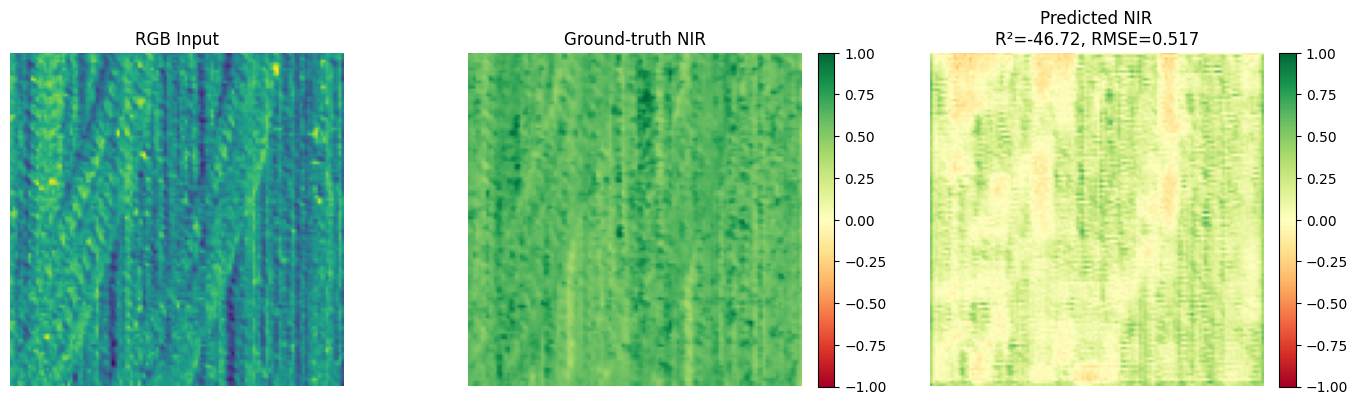

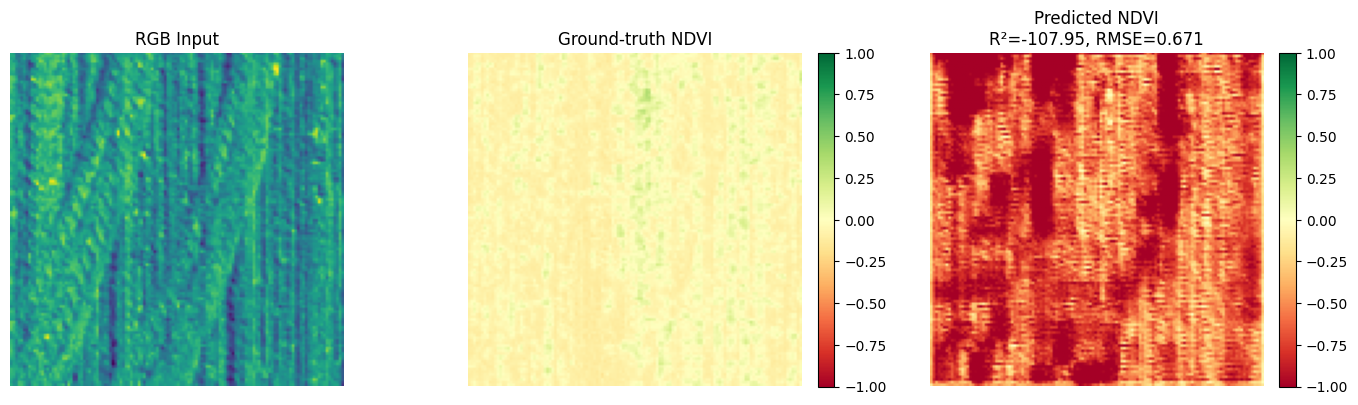

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# Flatten arrays for metrics
r2 = r2_score(nir_true.flatten(), to_numpy(nir_pred).flatten())
rmse = np.sqrt(mean_squared_error(nir_true.flatten(), to_numpy(nir_pred).flatten()))


def show_ndvi_comparison(rgb, nir_true, nir_pred, title="NIR",cmap="RdYlGn"):
    plt.figure(figsize=(14, 4))
    
    # RGB
    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("RGB Input")
    plt.axis("off")

    # True NDVI
    plt.subplot(1, 3, 2)
    plt.imshow(np.transpose(nir_true, (1, 2, 0)), cmap=cmap, vmin=-1, vmax=1)
    plt.title(f"Ground-truth {title}")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    # Predicted NDVI + Residual
    plt.subplot(1, 3, 3)
    plt.imshow(np.transpose(nir_pred, (1, 2, 0)), cmap=cmap, vmin=-1, vmax=1)
    plt.title(f"Predicted {title}\nR²={r2:.2f}, RMSE={rmse:.3f}")
    # plt.title(f"Predicted NDVI")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_ndvi_comparison(rgb[0], nir_true[0], to_numpy(nir_pred[0]), title="NIR")
r2 = r2_score(ndvi_true.flatten(), to_numpy(ndvi_pred).flatten())
rmse = np.sqrt(mean_squared_error(ndvi_true.flatten(), to_numpy(ndvi_pred).flatten()))
show_ndvi_comparison(rgb[0], ndvi_true[0], to_numpy(ndvi_pred[0]), title="NDVI")


## Visualize RGB / NIR / NDVI (core qualitative result)

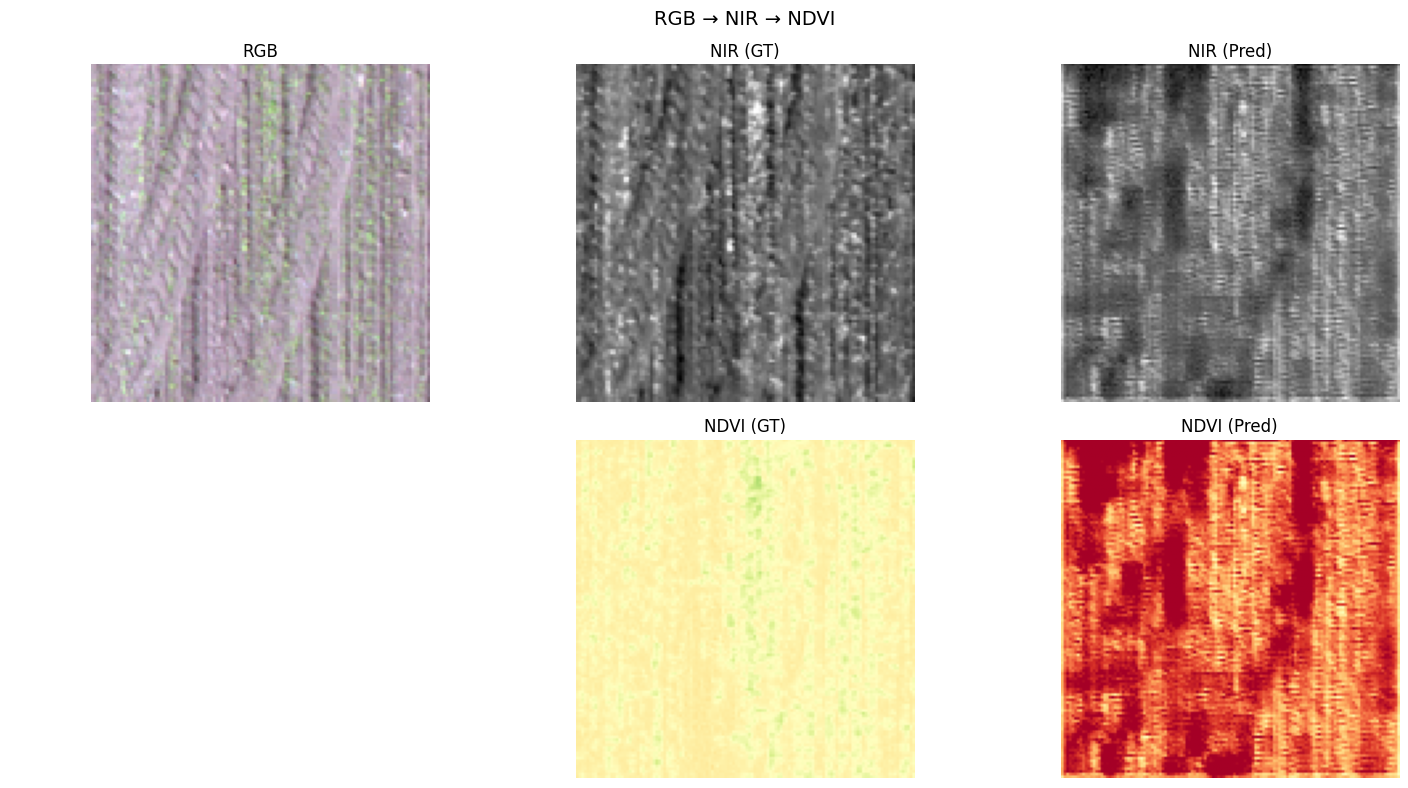

In [25]:
def plot_rgb_nir_ndvi(
    rgb, 
    nir_true,
    nir_pred,
    ndvi_true=None,
    save_path=None,
    title_prefix=""
):
    """
    rgb: (3,H,W) in [0,1]
    nir_*: (1,H,W) in [0,1]
    """

    rgb = to_numpy(rgb)
    nir_t = to_numpy(nir_true[0])
    nir_p = to_numpy(nir_pred[0])

    if ndvi_true is not None:
        ndvi_t = to_numpy(ndvi_true[0])
    else:
        ndvi_t = (nir_t - rgb[0]) / (nir_t + rgb[0] + 1e-6)
    ndvi_p = (nir_p - rgb[0]) / (nir_p + rgb[0] + 1e-6)

    fig, axs = plt.subplots(2, 3, figsize=(15, 8))

    axs[0,0].imshow(np.transpose(rgb, (1,2,0)))
    axs[0,0].set_title("RGB")

    axs[0,1].imshow(np.transpose(nir_t, (1,2,0)), cmap="gray")
    axs[0,1].set_title("NIR (GT)")

    axs[0,2].imshow(np.transpose(nir_p, (1,2,0)), cmap="gray")
    axs[0,2].set_title("NIR (Pred)")

    ndvi_norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    axs[1,1].imshow(np.transpose(ndvi_t, (1,2,0)), cmap="RdYlGn", norm=ndvi_norm)
    axs[1,1].set_title("NDVI (GT)")

    axs[1,2].imshow(np.transpose(ndvi_p, (1,2,0)), cmap="RdYlGn", norm=ndvi_norm)
    axs[1,2].set_title("NDVI (Pred)")

    axs[1,0].axis("off")

    for ax in axs.flat:
        ax.axis("off")

    plt.suptitle(title_prefix + "RGB → NIR → NDVI", fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

plot_rgb_nir_ndvi(rgb, nir_true, nir_pred, ndvi_true)


## Error Maps (critical for diagnosing failure modes)

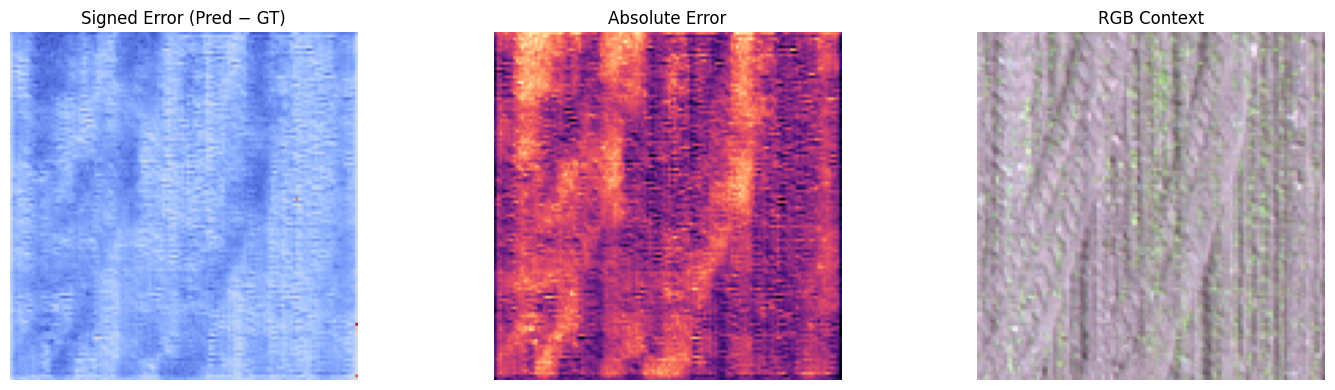

In [26]:
def plot_error_maps(
    nir_true, nir_pred,
    rgb=None,
    save_path=None
):
    nir_t = to_numpy(nir_true[0])
    nir_p = to_numpy(nir_pred[0])

    err = nir_p - nir_t
    abs_err = np.abs(err)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    axs[0].imshow(np.transpose(err, (1,2,0)), cmap="coolwarm",
                  norm=TwoSlopeNorm(vcenter=0))
    axs[0].set_title("Signed Error (Pred − GT)")

    axs[1].imshow(np.transpose(abs_err, (1,2,0)), cmap="magma")
    axs[1].set_title("Absolute Error")

    if rgb is not None:
        axs[2].imshow(to_numpy(np.transpose(rgb, (1,2,0))))
        axs[2].set_title("RGB Context")
    else:
        axs[2].axis("off")

    for ax in axs:
        ax.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()



plot_error_maps(nir_true, nir_pred, rgb)


## Scatter plot: Prediction vs Ground Truth
This reveals bias, saturation, and collapse

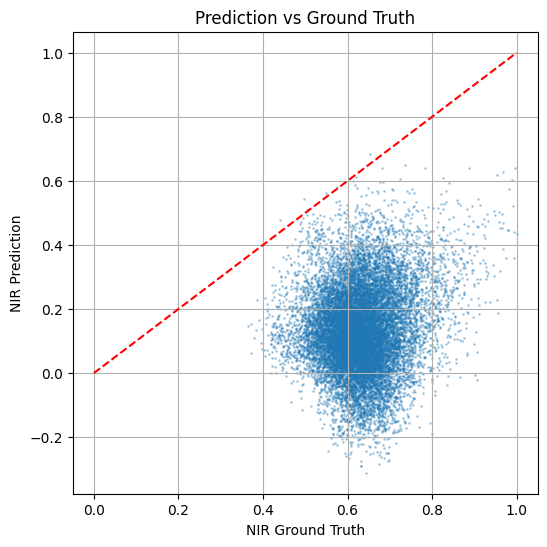

In [27]:
def plot_scatter_pred_vs_gt(
    nir_true, nir_pred,
    sample_size=200_000,
    save_path=None
):
    y = to_numpy(nir_true).ravel()
    y_hat = to_numpy(nir_pred).ravel()

    # subsample for speed
    if y.size > sample_size:
        idx = np.random.choice(y.size, sample_size, replace=False)
        y = y[idx]
        y_hat = y_hat[idx]

    plt.figure(figsize=(6,6))
    plt.scatter(y, y_hat, s=1, alpha=0.3)
    plt.plot([0,1], [0,1], "r--")
    plt.xlabel("NIR Ground Truth")
    plt.ylabel("NIR Prediction")
    plt.title("Prediction vs Ground Truth")
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

plot_scatter_pred_vs_gt(nir_true, nir_pred)


## Error Histogram
distributional sanity

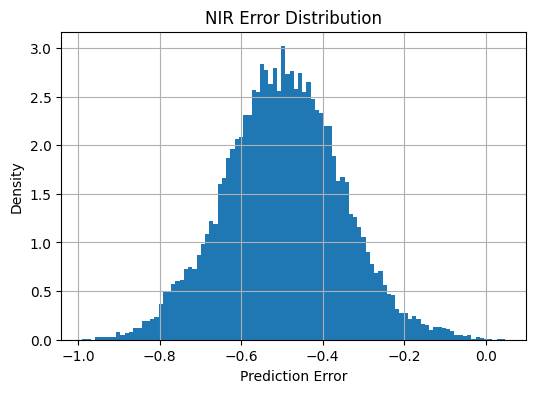

In [28]:
def plot_error_histogram(
    nir_true, nir_pred,
    bins=100,
    save_path=None
):
    nir_pred = to_numpy(nir_pred)
    nir_true = to_numpy(nir_true)
    err = (nir_pred - nir_true).ravel()

    plt.figure(figsize=(6,4))
    plt.hist(err, bins=bins, density=True)
    plt.xlabel("Prediction Error")
    plt.ylabel("Density")
    plt.title("NIR Error Distribution")
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
plot_error_histogram(nir_true, nir_pred)


## NDVI comparison plot (ecological correctness)

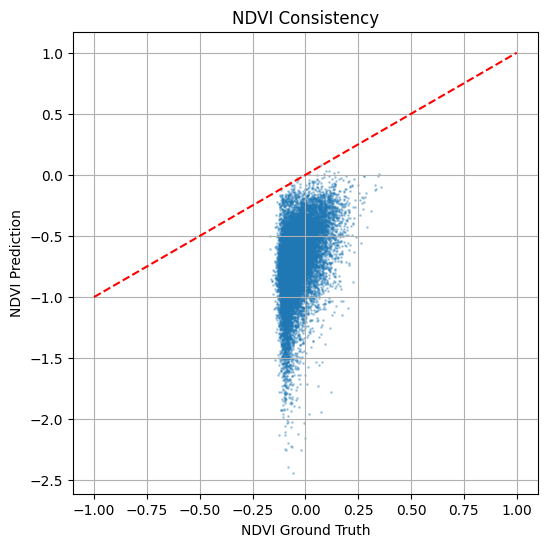

In [29]:
def plot_ndvi_scatter(
    rgb, nir_true, nir_pred, ndvi_true=None,
    save_path=None
):
    rgb = to_numpy(rgb)
    nir_t = to_numpy(nir_true[0])
    nir_p = to_numpy(nir_pred[0])

    red = rgb[0]
    if ndvi_true is not None:
        ndvi_t = to_numpy(ndvi_true[0])
    else:
        ndvi_t = (nir_t - red) / (nir_t + red + 1e-6)
    ndvi_p = (nir_p - red) / (nir_p + red + 1e-6)

    y = ndvi_t.ravel()
    y_hat = ndvi_p.ravel()

    plt.figure(figsize=(6,6))
    plt.scatter(y, y_hat, s=1, alpha=0.3)
    plt.plot([-1,1], [-1,1], "r--")
    plt.xlabel("NDVI Ground Truth")
    plt.ylabel("NDVI Prediction")
    plt.title("NDVI Consistency")
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

plot_ndvi_scatter(rgb, nir_true, nir_pred, ndvi_true)


## Validation curve plots (training dynamics)

In [25]:
def plot_training_curves(history, save_path=None):
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    axs[0,0].plot(history["train_losses"], label="Train")
    axs[0,0].plot(history["val_losses"], label="Val")
    axs[0,0].set_title("Loss")
    axs[0,0].legend()

    axs[0,1].plot(history["rmse"])
    axs[0,1].set_title("RMSE")

    axs[1,0].plot(history["mae"])
    axs[1,0].set_title("MAE")

    axs[1,1].plot(history["ssim"])
    axs[1,1].set_title("SSIM")

    for ax in axs.flat:
        ax.grid(True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()
if history is not None:
    plot_training_curves(history)
else:
    print("No training history available for plotting.")


NameError: name 'history' is not defined

In [ ]:
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
